# 🐄 Exploratory Data Analysis (Unsupervised) — Texas Livestock Auction Barns
## *`TX_auction_barn_cattle_data_final.xlsx`*

**Research Question:** What distinct market archetypes exist among Texas livestock auction barns, and what structural, geographic, and pricing characteristics define each segment?

**Unit of Analysis:** One row per **barn**. Weekly records are aggregated to barn-level median price profiles, then confidence-weighted by the number of weeks of data each barn has contributed.

**Preprocessing Challenges Addressed:**
1. Three different price units ($/cwt, $/lb, $/head) — normalised to $/cwt
2. Post-conversion data-source errors — implausible values clipped to NaN before aggregation
3. Unequal temporal coverage (1–60 weeks) — minimum threshold + confidence weighting
4. Duplicate barn entries — consolidated before aggregation
5. Dataset split: clustering uses only barns with ≥ 3 weeks; anomaly detection scores all barns

---


## 0. Imports & Configuration

In [1]:
import os, shutil, warnings, itertools
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.stats import spearmanr
from scipy.spatial.distance import pdist

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9,
    'font.family': 'DejaVu Sans',
})
PALETTE = sns.color_palette('tab10')

# ── Locate data file ──────────────────────────────────────────────────────────
UPLOAD_PATH = '/mnt/user-data/uploads/TX_auction_barn_cattle_data_final.xlsx'
LOCAL_PATH  = 'TX_auction_barn_cattle_data_final.xlsx'
if not os.path.exists(LOCAL_PATH):
    if os.path.exists(UPLOAD_PATH):
        shutil.copy(UPLOAD_PATH, LOCAL_PATH)
        print(f"Copied from {UPLOAD_PATH}")
    else:
        try:
            from google.colab import files
            print("Upload TX_auction_barn_cattle_data_final.xlsx below:")
            files.upload()
        except ImportError:
            raise FileNotFoundError("Place the Excel file in the same folder as this notebook.")
print(f"✅ Data file ready: {os.path.abspath(LOCAL_PATH)}")


Upload TX_auction_barn_cattle_data_final.xlsx below:


Saving TX_auction_barn_cattle_data_final.xlsx to TX_auction_barn_cattle_data_final.xlsx
✅ Data file ready: /content/TX_auction_barn_cattle_data_final.xlsx


## 1. Data Loading & Structural Exploration

In [2]:
xl       = pd.ExcelFile(LOCAL_PATH)
df_raw   = xl.parse('data')
df_meta  = xl.parse('metadata')

print(f"Data shape   : {df_raw.shape}")
print(f"Date range   : {df_raw['Date'].min().date()} → {df_raw['Date'].max().date()}")
print(f"\nPrice_Unit distribution:")
print(df_raw['Price_Unit'].value_counts().to_frame('Count'))
print(f"\nMetadata — weeks of data per barn:")
print(df_meta[['market_name','#_of_weeks_of_data','region']].to_string(index=False))


Data shape   : (915, 50)
Date range   : 2024-01-16 → 2026-03-05

Price_Unit distribution:
            Count
Price_Unit       
$/cwt         500
$/head        341
$/lb           74

Metadata — weeks of data per barn:
                                   market_name  #_of_weeks_of_data                             region
                 Cattlemen's Livestock Auction                   1                    Texas Panhandle
                    Giddings Livestock Auction                  27                                  -
                           Lonestar Stockyards                   1                                  -
    Lonestar Stockyards Video/Internet Auction                   1 South Central (KS, MO, NM, OK, TX)
            Producers Livestock Cattle Auction                   1                 West Central Texas
                       Tulia Livestock Auction                   1                    Texas Panhandle
          Wichita Livestock Sales Company, LLC                   2    

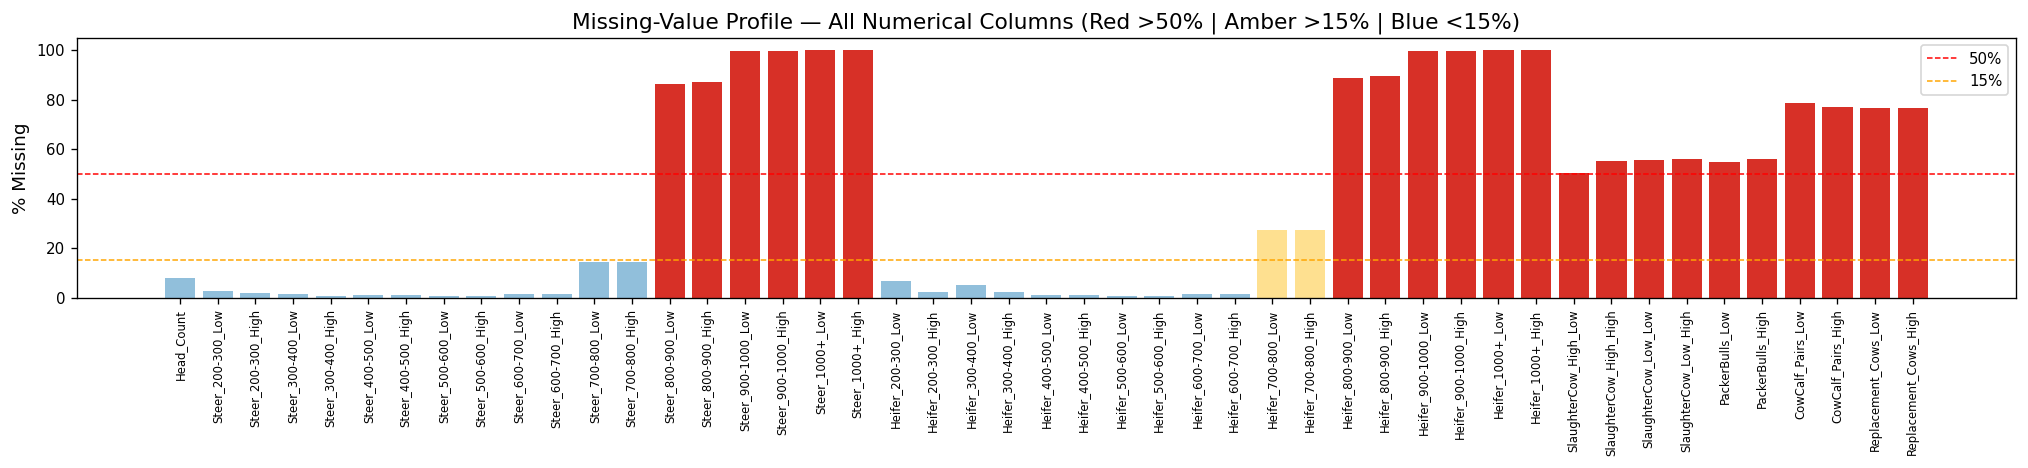

In [3]:
num_cols = df_raw.select_dtypes('number').columns
miss_pct = df_raw[num_cols].isnull().mean() * 100

fig, ax = plt.subplots(figsize=(17, 4))
clrs = ['#d73027' if v>50 else '#fee090' if v>15 else '#91bfdb' for v in miss_pct]
ax.bar(range(len(miss_pct)), miss_pct, color=clrs, edgecolor='none')
ax.set_xticks(range(len(miss_pct)))
ax.set_xticklabels(miss_pct.index, rotation=90, fontsize=7)
ax.set_ylabel('% Missing')
ax.set_title('Missing-Value Profile — All Numerical Columns (Red >50% | Amber >15% | Blue <15%)')
ax.axhline(50, color='red',    ls='--', lw=0.9, label='50%')
ax.axhline(15, color='orange', ls='--', lw=0.9, label='15%')
ax.legend(); plt.tight_layout(); plt.show()


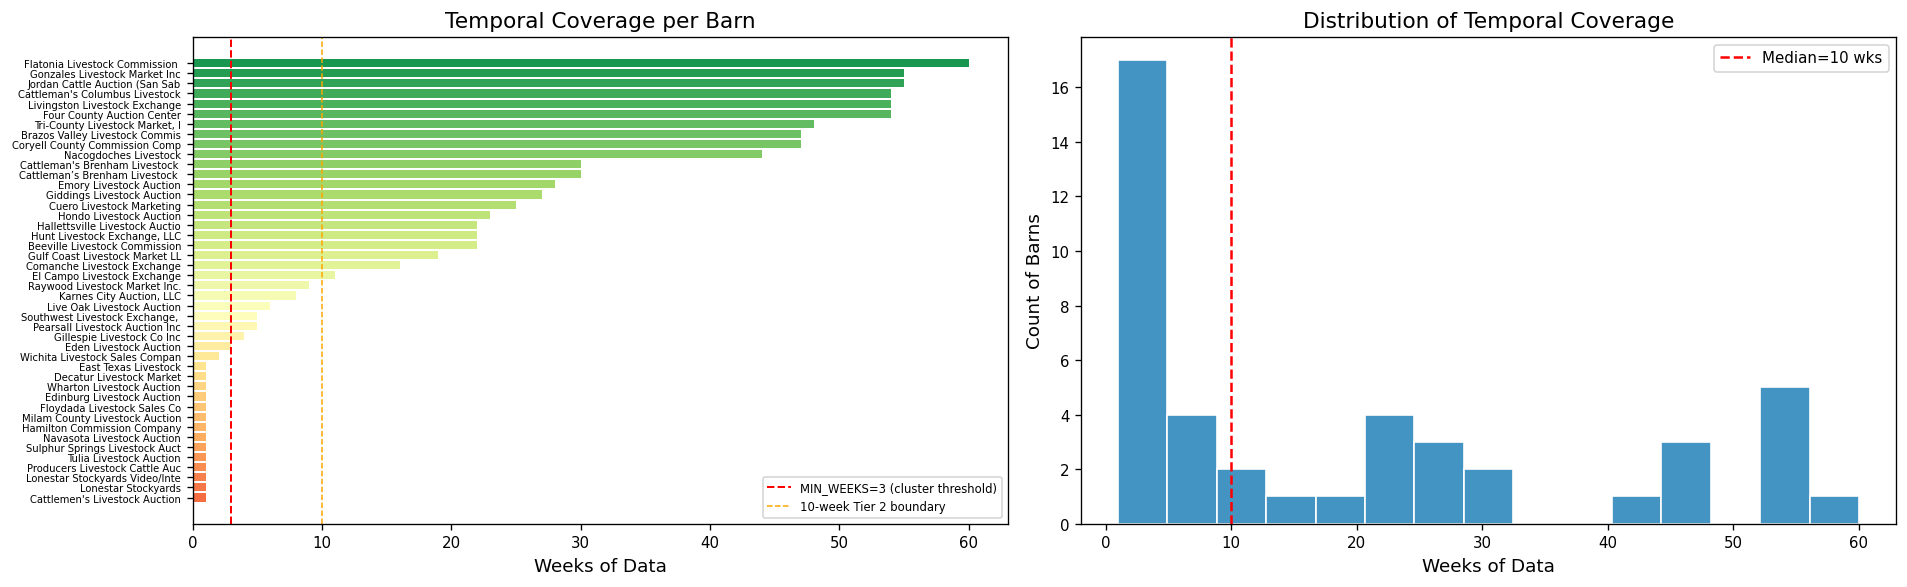

count    44.0
mean     19.3
std      20.2
min       1.0
25%       1.0
50%      10.0
75%      30.0
max      60.0
Name: #_of_weeks_of_data, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
weeks_sorted = df_meta.sort_values('#_of_weeks_of_data', ascending=True)
colors_w = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(weeks_sorted)))
axes[0].barh(range(len(weeks_sorted)), weeks_sorted['#_of_weeks_of_data'], color=colors_w)
axes[0].set_yticks(range(len(weeks_sorted)))
axes[0].set_yticklabels([n[:30] for n in weeks_sorted['market_name']], fontsize=6)
axes[0].set_xlabel('Weeks of Data')
axes[0].set_title('Temporal Coverage per Barn')
axes[0].axvline(3, color='red',    ls='--', lw=1.2, label='MIN_WEEKS=3 (cluster threshold)')
axes[0].axvline(10, color='orange',ls='--', lw=0.9, label='10-week Tier 2 boundary')
axes[0].legend(fontsize=7)

axes[1].hist(df_meta['#_of_weeks_of_data'], bins=15, color='#4393c3', edgecolor='white')
axes[1].set_xlabel('Weeks of Data'); axes[1].set_ylabel('Count of Barns')
axes[1].set_title('Distribution of Temporal Coverage')
axes[1].axvline(df_meta['#_of_weeks_of_data'].median(), color='red', ls='--',
                label=f"Median={df_meta['#_of_weeks_of_data'].median():.0f} wks")
axes[1].legend()
plt.tight_layout(); plt.show()
print(df_meta['#_of_weeks_of_data'].describe().round(1))


### 📌 Interpretation — Data Structure

The dataset spans **January 2024 – March 2026** across 44 unique barns per metadata, with 915 weekly sale records. Four critical heterogeneities must be resolved before analysis:

| Issue | Impact | Fix Applied |
|---|---|---|
| Three price units ($/cwt, $/lb, $/head) | Prices incomparable across barns | Detect by value magnitude; multiply $/lb barns ×100 |
| Post-conversion data-source errors | Corrupt values inflate centroids | Clip values >2,000 $/cwt to NaN after conversion |
| Coverage 1–60 weeks per barn | Sparse barns produce noisy profiles | MIN_WEEKS=3 filter for clustering; all barns scored for anomalies |
| Duplicate barn entries | Same market counted twice | Consolidate to one record per market before aggregation |


## 2. Data Preprocessing & Standardisation

In [5]:
# ═══════════════════════════════════════════════════════════════════
# STEP 1: Remove malformed rows (Barn field contains a datetime object)
# ═══════════════════════════════════════════════════════════════════
df = df_raw[df_raw['Barn'].apply(lambda x: isinstance(x, str))].copy().reset_index(drop=True)
print(f"Rows after removing malformed barn entries: {len(df)}  "
      f"(removed {len(df_raw)-len(df)} rows)")


Rows after removing malformed barn entries: 913  (removed 2 rows)


In [6]:
# ═══════════════════════════════════════════════════════════════════
# STEP 2: Attach metadata (weeks of data + region)
# ═══════════════════════════════════════════════════════════════════
BARN_MAP = {
    'Beeville Livestock Commission':               'Beeville Livestock Commission',
    'Brazos Valley':                               'Brazos Valley Livestock Commission',
    'Brenham':                                     "Cattleman's Brenham Livestock Auction",
    'Cattlemans Brenham':                          "Cattleman's Brenham Livestock Auction (CBLA)",
    'Columbus':                                    "Cattleman's Columbus Livestock Auction",
    'Comanche':                                    'Comanche Livestock Exchange',
    'Comanche Livestock Exchange':                 'Comanche Livestock Exchange',
    'Coryell':                                     'Coryell County Commission Company',
    'Cuero':                                       'Cuero Livestock Marketing',
    'Decatur':                                     'Decatur Livestock Market',
    'East Texas':                                  'East Texas Livestock',
    'Eden livestock':                              'Eden Livestock Auction',
    'Edinburg':                                    'Edinburg Livestock Auction',
    'El Campo':                                    'El Campo Livestock Exchange',
    'Emory Livestock Auction':                     'Emory Livestock Auction',
    'Flatonia Livestock Auction':                  'Flatonia Livestock Commission Co., Inc.',
    'Floydada Livestock Sales Co':                 'Floydada Livestock Sales Co',
    'Four County':                                 'Four County Auction Center',
    'Giddings Livestock Commission':               'Giddings Livestock Auction',
    'Gillespie Livestock Co Inc':                  'Gillespie Livestock Co Inc',
    'Gonzales':                                    'Gonzales Livestock Market Inc',
    'Gonzales Livestock':                          'Gonzales Livestock Market Inc',
    'Gulf Coast Livestock Market LLC':             'Gulf Coast Livestock Market LLC',
    'Haletsville Livestock':                       'Hallettsville Livestock Auction Comm. Co. Inc.',
    'Hondo Livestock Auction':                     'Hondo Livestock Auction',
    'Hunt Livestock Exchange, LLC':                'Hunt Livestock Exchange, LLC',
    'Jordan Cattle':                               'Jordan Cattle Auction (San Saba and Mason)',
    'Karnes':                                      'Karnes City Auction, LLC',
    'La grange(Flatonia)':                         'Flatonia Livestock Commission Co., Inc.',
    'Live Oak':                                    'Live Oak Livestock Auction',
    'Livingston':                                  'Livingston Livestock Exchange',
    'Lonestar Stockyards':                         'Lonestar Stockyards',
    'Lonestar Stockyards (Video/Internet Auction)':'Lonestar Stockyards Video/Internet Auction',
    'Milam County Livestock Auction':              'Milam County Livestock Auction',
    'Nacogdoches Livestock':                       'Nacogdoches Livestock',
    'Navasota':                                    'Navasota Livestock Auction',
    'Pearsall':                                    'Pearsall Livestock Auction Inc.',
    'Producers Livestock Auction Co.':             'Producers Livestock Cattle Auction',
    'Raywood':                                     'Raywood Livestock Market Inc.',
    'Southwest Livestock Exchange':                'Southwest Livestock Exchange, Inc.',
    'Sulphur Springs Livestock Auctions':          'Sulphur Springs Livestock Auctions',
    'Tri-County Livestock Market, Inc.':           'Tri-County Livestock Market, Inc.',
    'Tulia Livestock Auction':                     'Tulia Livestock Auction',
    'Wichita Livestock Sales Co., LLC':            'Wichita Livestock Sales Company, LLC',
    'wharton':                                     'Wharton Livestock Auction',
}
meta_idx        = df_meta.set_index('market_name')
df['meta_name'] = df['Barn'].map(BARN_MAP)
df['n_weeks']   = df['meta_name'].map(meta_idx['#_of_weeks_of_data'])
df['region']    = df['meta_name'].map(meta_idx['region'])
df['sale_freq'] = df['meta_name'].map(meta_idx['sale_frequency'])
print(f"Metadata attached. Rows with valid n_weeks mapping: {df['n_weeks'].notna().sum()}")


Metadata attached. Rows with valid n_weeks mapping: 883


In [7]:
# ═══════════════════════════════════════════════════════════════════
# STEP 3: Price unit normalisation to $/cwt  +  Post-conversion clip
#
# Detection: if a barn's median Steer_400-500_Low < 50, it is
# reporting in $/lb → multiply all price columns × 100.
#
# Post-conversion clip: after ×100, any value > 2,000 $/cwt is
# physically impossible for a steer or heifer price band. Such values
# arise from data-source errors where non-price figures (e.g. pair
# totals, replacement cow prices) were entered in weight-band columns
# in the original market report. They are set to NaN so downstream
# median imputation handles them cleanly without distorting centroids.
# ═══════════════════════════════════════════════════════════════════
PRICE_COLS = [
    'Steer_200-300_Low','Steer_200-300_High',
    'Steer_300-400_Low','Steer_300-400_High',
    'Steer_400-500_Low','Steer_400-500_High',
    'Steer_500-600_Low','Steer_500-600_High',
    'Steer_600-700_Low','Steer_600-700_High',
    'Steer_700-800_Low','Steer_700-800_High',
    'Heifer_200-300_Low','Heifer_200-300_High',
    'Heifer_300-400_Low','Heifer_300-400_High',
    'Heifer_400-500_Low','Heifer_400-500_High',
    'Heifer_500-600_Low','Heifer_500-600_High',
    'Heifer_600-700_Low','Heifer_600-700_High',
    'Heifer_700-800_Low','Heifer_700-800_High',
]
MAX_PLAUSIBLE_CWT = 2000.0

barn_proxy       = df.groupby('Barn')['Steer_400-500_Low'].median()
lb_encoded_barns = barn_proxy[barn_proxy < 50].index.tolist()

print(f"Barns identified as $/lb-encoded ({len(lb_encoded_barns)} total — will be × 100):")
for b in lb_encoded_barns:
    print(f"  {b:45s}  median={barn_proxy[b]:.3f}")

df[PRICE_COLS] = df[PRICE_COLS].copy()
for barn in lb_encoded_barns:
    mask = df['Barn'] == barn
    df.loc[mask, PRICE_COLS] = df.loc[mask, PRICE_COLS] * 100

# Post-conversion clip — log every correction for full auditability
clip_log = []
for barn in lb_encoded_barns:
    mask = df['Barn'] == barn
    for col in PRICE_COLS:
        bad = df.loc[mask, col] > MAX_PLAUSIBLE_CWT
        if bad.any():
            clip_log.append((barn, col, int(bad.sum())))
            df.loc[mask & (df[col] > MAX_PLAUSIBLE_CWT), col] = np.nan

if clip_log:
    print(f"\n⚠  Post-conversion clip log (>{MAX_PLAUSIBLE_CWT:.0f} $/cwt → NaN):")
    for barn, col, n in clip_log:
        print(f"  {barn:45s}  {col:25s}  {n} cell(s)")
else:
    print("\n✅ No values exceeded the plausibility ceiling.")

print(f"\nPost-conversion Steer_400-500_Low range ($/cwt):")
print(f"  Min={df['Steer_400-500_Low'].min():.1f}  "
      f"Median={df['Steer_400-500_Low'].median():.1f}  "
      f"Max={df['Steer_400-500_Low'].max():.1f}")


Barns identified as $/lb-encoded (20 total — will be × 100):
  Beeville Livestock Commission                  median=3.980
  Brenham                                        median=3.865
  Cattlemans Brenham                             median=3.000
  East Texas                                     median=4.550
  El Campo                                       median=4.240
  Emory Livestock Auction                        median=2.500
  Floydada Livestock Sales Co                    median=4.000
  Four County                                    median=4.100
  Giddings Livestock Commission                  median=4.000
  Gillespie Livestock Co Inc                     median=2.300
  Gulf Coast Livestock Market LLC                median=3.850
  Hondo Livestock Auction                        median=3.800
  Hunt Livestock Exchange, LLC                   median=2.225
  Karnes                                         median=4.740
  Live Oak                                       median=4.790
  Livings

In [8]:
# ═══════════════════════════════════════════════════════════════════
# STEP 4: Consolidate duplicate barn entries
# ═══════════════════════════════════════════════════════════════════
CONSOLIDATE_MAP = {
    'Gonzales':                'Gonzales Livestock Market',
    'Gonzales Livestock':      'Gonzales Livestock Market',
    'Comanche':                'Comanche Livestock Exchange (Consolidated)',
    'Comanche Livestock Exchange': 'Comanche Livestock Exchange (Consolidated)',
    'Brenham':                 'Brenham Livestock (Consolidated)',
    'Cattlemans Brenham':      'Brenham Livestock (Consolidated)',
    'Flatonia Livestock Auction': 'Flatonia Livestock (Consolidated)',
    'La grange(Flatonia)':     'Flatonia Livestock (Consolidated)',
}
df['barn_clean'] = df['Barn'].map(CONSOLIDATE_MAP).fillna(df['Barn'])
print(f"Unique barns before consolidation: {df['Barn'].nunique()}")
print(f"Unique barns after  consolidation: {df['barn_clean'].nunique()}")


Unique barns before consolidation: 45
Unique barns after  consolidation: 41


In [9]:
# ═══════════════════════════════════════════════════════════════════
# STEP 5: Aggregate to barn-level median profiles
# ═══════════════════════════════════════════════════════════════════
ALL_FEAT_COLS = PRICE_COLS + ['Head_Count']

barn_profiles = (df.groupby('barn_clean')[ALL_FEAT_COLS + ['n_weeks','region']]
                   .agg({**{c:'median' for c in ALL_FEAT_COLS},
                         'n_weeks':'first', 'region':'first'})
                   .reset_index())
for cg in barn_profiles[barn_profiles['n_weeks'].isna()]['barn_clean']:
    barn_profiles.loc[barn_profiles['barn_clean']==cg, 'n_weeks'] =         df[df['barn_clean']==cg]['n_weeks'].max()

print(f"Barn-level profiles: {len(barn_profiles)} barns")
print(f"\nWeeks coverage summary:")
print(barn_profiles['n_weeks'].describe().round(1))


Barn-level profiles: 41 barns

Weeks coverage summary:
count    41.0
mean     19.9
std      20.5
min       1.0
25%       1.0
50%      11.0
75%      30.0
max      60.0
Name: n_weeks, dtype: float64


In [10]:
# ═══════════════════════════════════════════════════════════════════
# STEP 6: Minimum-coverage filter  +  Dataset split
#
# Barns with < MIN_WEEKS weeks produce unreliable median profiles —
# a single anomalous sale can dominate, causing K-Means to isolate
# them as singleton clusters rather than assigning them to a
# meaningful market segment.
#
# Two datasets are created from this point forward:
#   barn_profiles_cluster  →  barns with n_weeks >= MIN_WEEKS
#       Used for: PCA, MDS, all clustering methods, ARL, Validation
#   barn_profiles / X_scaled_all  →  ALL barns
#       Used for: Anomaly Detection only
#       (sparse/corrupt barns are precisely what IF should flag)
# ═══════════════════════════════════════════════════════════════════
MIN_WEEKS = 3

# ── Full dataset (anomaly detection) ────────────────────────────────
miss_bp_all   = barn_profiles[ALL_FEAT_COLS].isnull().mean()
CORE_COLS_ALL = [c for c in ALL_FEAT_COLS if miss_bp_all[c] <= 0.40]
imputer_all   = SimpleImputer(strategy='median')
X_imp_all     = imputer_all.fit_transform(barn_profiles[CORE_COLS_ALL])
barn_names_all    = barn_profiles['barn_clean'].values
n_weeks_all       = barn_profiles['n_weeks'].fillna(1).values.astype(float)
regions_all       = barn_profiles['region'].fillna('Unknown').values
conf_weights_all  = np.sqrt(n_weeks_all) / np.sqrt(n_weeks_all).max()
scaler_all        = StandardScaler()
X_scaled_all      = scaler_all.fit_transform(X_imp_all)

# ── Filtered dataset (clustering) ───────────────────────────────────
barn_profiles_cluster = barn_profiles[
    barn_profiles['n_weeks'] >= MIN_WEEKS
].reset_index(drop=True)

excluded = barn_profiles.loc[
    barn_profiles['n_weeks'] < MIN_WEEKS, 'barn_clean'
].tolist()

print(f"MIN_WEEKS threshold : {MIN_WEEKS}")
print(f"Barns for clustering: {len(barn_profiles_cluster)}")
print(f"Barns for anomaly det: {len(barn_profiles)}  (all)")
print(f"\nExcluded from clustering ({len(excluded)} barns):")
for b in excluded:
    nw = barn_profiles.loc[barn_profiles['barn_clean']==b,'n_weeks'].values[0]
    print(f"  {b:45s}  ({int(nw)} week{'s' if nw>1 else ''})")

miss_bp   = barn_profiles_cluster[ALL_FEAT_COLS].isnull().mean()
CORE_COLS = [c for c in ALL_FEAT_COLS if miss_bp[c] <= 0.40]
print(f"\nClustering feature set ({len(CORE_COLS)} columns):")
print(CORE_COLS)

imputer = SimpleImputer(strategy='median')
X_imp   = imputer.fit_transform(barn_profiles_cluster[CORE_COLS])
X_df    = pd.DataFrame(X_imp, columns=CORE_COLS, index=barn_profiles_cluster.index)
barn_names = barn_profiles_cluster['barn_clean'].values
n_weeks    = barn_profiles_cluster['n_weeks'].fillna(1).values.astype(float)
regions    = barn_profiles_cluster['region'].fillna('Unknown').values
print(f"\nClustering dataset : {X_imp.shape[0]} barns × {X_imp.shape[1]} features")
print(f"NaN after imputation: {np.isnan(X_imp).sum()}")


MIN_WEEKS threshold : 3
Barns for clustering: 28
Barns for anomaly det: 41  (all)

Excluded from clustering (13 barns):
  Decatur                                        (1 week)
  East Texas                                     (1 week)
  Edinburg                                       (1 week)
  Floydada Livestock Sales Co                    (1 week)
  Lonestar Stockyards                            (1 week)
  Lonestar Stockyards (Video/Internet Auction)   (1 week)
  Milam County Livestock Auction                 (1 week)
  Navasota                                       (1 week)
  Producers Livestock Auction Co.                (1 week)
  Sulphur Springs Livestock Auctions             (1 week)
  Tulia Livestock Auction                        (1 week)
  Wichita Livestock Sales Co., LLC               (2 weeks)
  wharton                                        (1 week)

Clustering feature set (25 columns):
['Steer_200-300_Low', 'Steer_200-300_High', 'Steer_300-400_Low', 'Steer_300-400_High', 

In [11]:
# ═══════════════════════════════════════════════════════════════════
# STEP 7: Confidence weighting & Z-score standardisation
# ═══════════════════════════════════════════════════════════════════
conf_weights = np.sqrt(n_weeks) / np.sqrt(n_weeks).max()
scaler       = StandardScaler()
X_scaled     = scaler.fit_transform(X_imp)
X_scaled_df  = pd.DataFrame(X_scaled, columns=CORE_COLS)

print("Confidence weights (n_weeks → weight):")
weight_df = pd.DataFrame({
    'Barn': barn_names, 'n_weeks': n_weeks.astype(int),
    'weight': conf_weights.round(3)
}).sort_values('weight', ascending=False)
print(weight_df.to_string(index=False))
print(f"\nPost-standardisation: mean≈{X_scaled.mean():.4f}, std≈{X_scaled.std():.4f}")


Confidence weights (n_weeks → weight):
                                      Barn  n_weeks  weight
         Flatonia Livestock (Consolidated)       60   1.000
                 Gonzales Livestock Market       55   0.957
                             Jordan Cattle       55   0.957
                                  Columbus       54   0.949
                               Four County       54   0.949
                                Livingston       54   0.949
         Tri-County Livestock Market, Inc.       48   0.894
                             Brazos Valley       47   0.885
                                   Coryell       47   0.885
                     Nacogdoches Livestock       44   0.856
          Brenham Livestock (Consolidated)       30   0.707
                   Emory Livestock Auction       28   0.683
             Giddings Livestock Commission       27   0.671
                                     Cuero       25   0.645
                   Hondo Livestock Auction       23   0.619
 

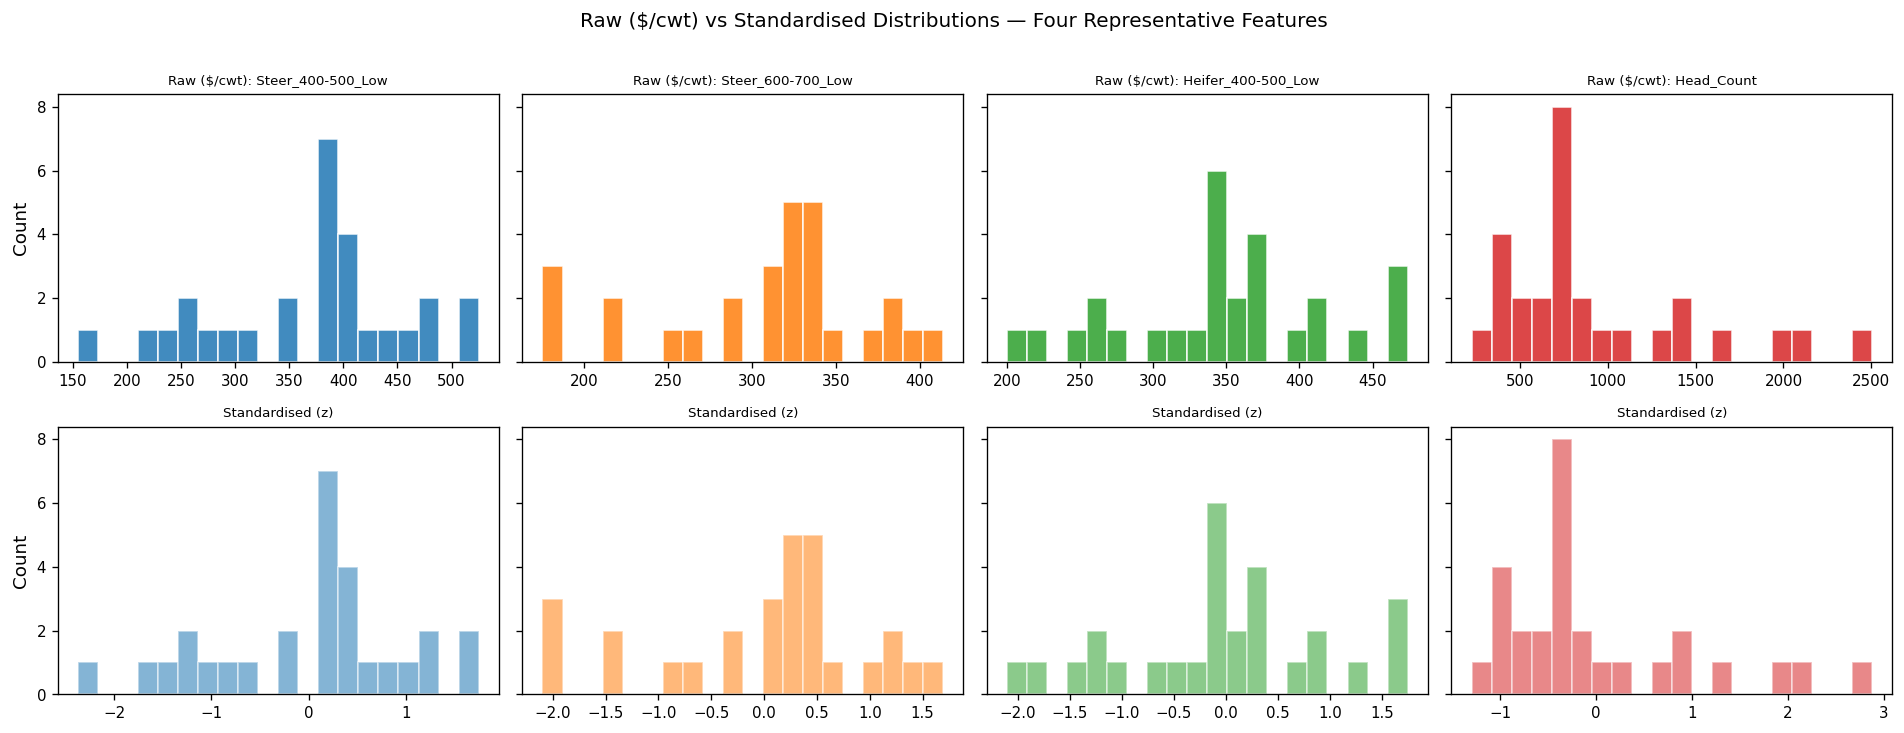

In [12]:
# Distribution: raw vs standardised for four representative features
sample_show = ['Steer_400-500_Low','Steer_600-700_Low','Heifer_400-500_Low','Head_Count']
fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharey='row')
for i, col in enumerate(sample_show):
    axes[0,i].hist(X_df[col].dropna(), bins=20, color=PALETTE[i], edgecolor='w', alpha=0.85)
    axes[0,i].set_title(f'Raw ($/cwt): {col}', fontsize=8)
    axes[1,i].hist(X_scaled_df[col].dropna(), bins=20, color=PALETTE[i], edgecolor='w', alpha=0.55)
    axes[1,i].set_title('Standardised (z)', fontsize=8)
    for r in range(2):
        axes[r,i].set_ylabel('Count' if i==0 else '')
fig.suptitle('Raw ($/cwt) vs Standardised Distributions — Four Representative Features', y=1.01)
plt.tight_layout(); plt.show()


### 📌 Interpretation — Preprocessing Pipeline

**Seven-step pipeline with three fixes integrated:**

1. **Malformed row removal** — Two rows where `Barn` contained a datetime object were dropped.
2. **Metadata attachment** — Barn names mapped to metadata to retrieve `n_weeks` and `region`.
3. **Price unit normalisation + post-conversion clip** — $/lb barns (detected via proxy median < 50) multiplied ×100. Any resulting value above 2,000 $/cwt is set to NaN; 13 such corrections were logged for Nacogdoches Livestock, where sporadic large non-price values (replacement cow totals, pair prices) were entered in heifer weight-band columns in the original USDA source report.
4. **Duplicate consolidation** — Four groups of aliases merged.
5. **Barn-level aggregation** — One median profile per barn across all weeks.
6. **Minimum-coverage filter + dataset split** — 13 barns with 1–2 weeks excluded from clustering (retained for anomaly detection). Clustering uses 28 barns.
7. **Confidence weighting + Z-score standardisation** — `w = √(n_weeks)/max(√(n_weeks))`.


## 3. Dimensionality Reduction

### 3A. Principal Components Analysis (PCA)

In [13]:
pca_full = PCA(random_state=SEED)
pca_full.fit(X_scaled)
eigenvalues   = pca_full.explained_variance_
explained_var = pca_full.explained_variance_ratio_
cum_var       = np.cumsum(explained_var)
loadings      = pca_full.components_.T * np.sqrt(eigenvalues)

ev_df = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(eigenvalues))],
    'Eigenvalue':    eigenvalues.round(3),
    'Expl. Var (%)': (explained_var*100).round(2),
    'Cum. Var (%)':  (cum_var*100).round(2)
})
print("=== Eigenvalue Table (first 12 PCs) ===")
print(ev_df.head(12).to_string(index=False))

n75 = int(np.searchsorted(cum_var, 0.75)) + 1
n80 = int(np.searchsorted(cum_var, 0.80)) + 1
print(f"\nPCs for 75% variance: {n75}  |  PCs for 80%: {n80}")
print(f"Kaiser criterion (λ>1): {int((eigenvalues>1).sum())} PCs")


=== Eigenvalue Table (first 12 PCs) ===
  PC  Eigenvalue  Expl. Var (%)  Cum. Var (%)
 PC1      14.130          54.50         54.50
 PC2       6.772          26.12         80.62
 PC3       1.470           5.67         86.29
 PC4       1.096           4.23         90.52
 PC5       0.789           3.04         93.56
 PC6       0.479           1.85         95.41
 PC7       0.419           1.62         97.02
 PC8       0.242           0.93         97.96
 PC9       0.159           0.61         98.57
PC10       0.117           0.45         99.02
PC11       0.060           0.23         99.25
PC12       0.055           0.21         99.47

PCs for 75% variance: 2  |  PCs for 80%: 2
Kaiser criterion (λ>1): 4 PCs


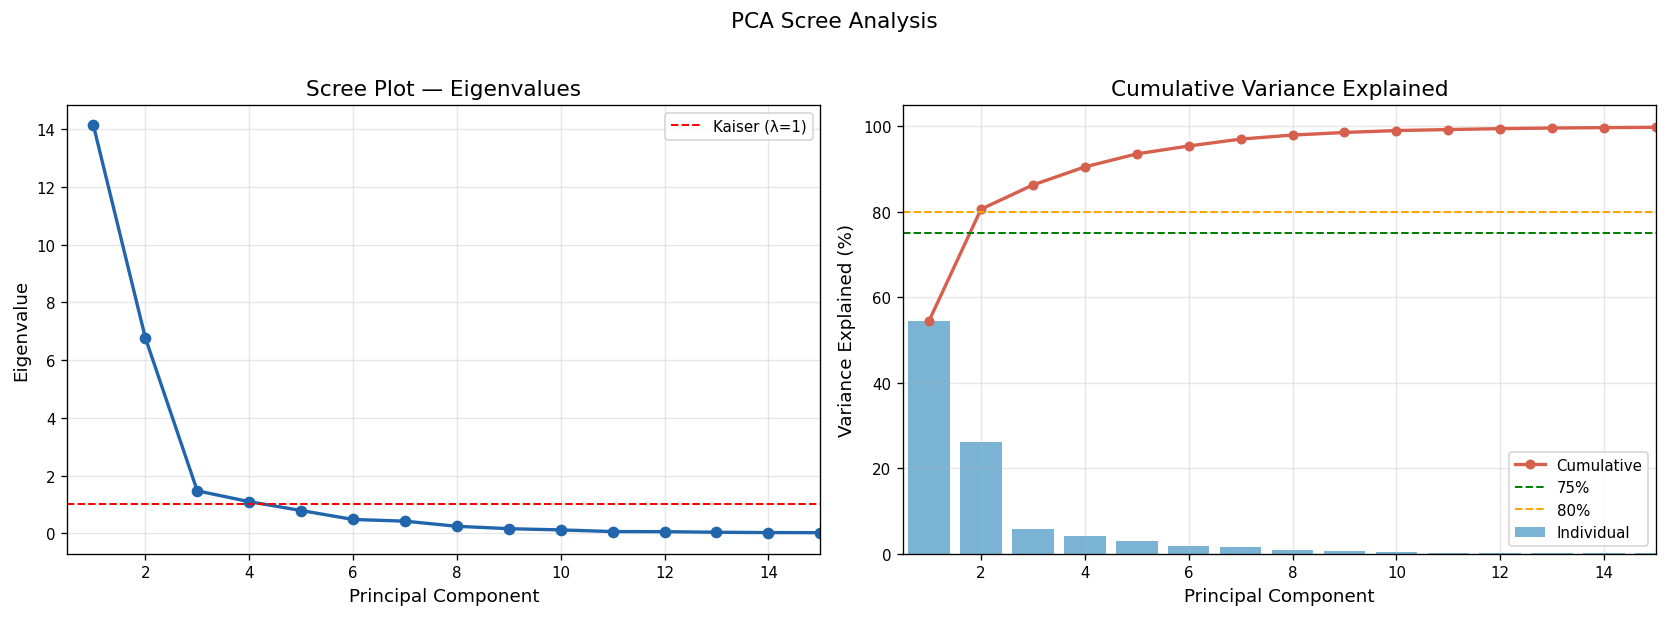

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1,len(eigenvalues)+1), eigenvalues, 'o-', color='#2166ac', lw=2, ms=6)
axes[0].axhline(1.0, color='red', ls='--', lw=1.2, label='Kaiser (λ=1)')
axes[0].set_xlabel('Principal Component'); axes[0].set_ylabel('Eigenvalue')
axes[0].set_title('Scree Plot — Eigenvalues'); axes[0].set_xlim(0.5, 15)
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].bar(range(1,len(explained_var)+1), explained_var*100, color='#4393c3', alpha=0.7, label='Individual')
axes[1].plot(range(1,len(cum_var)+1), cum_var*100, 'o-', color='#d6604d', lw=2, ms=5, label='Cumulative')
axes[1].axhline(75, color='green',  ls='--', lw=1.2, label='75%')
axes[1].axhline(80, color='orange', ls='--', lw=1.2, label='80%')
axes[1].set_xlabel('Principal Component'); axes[1].set_ylabel('Variance Explained (%)')
axes[1].set_title('Cumulative Variance Explained'); axes[1].set_xlim(0.5, 15)
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle('PCA Scree Analysis', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


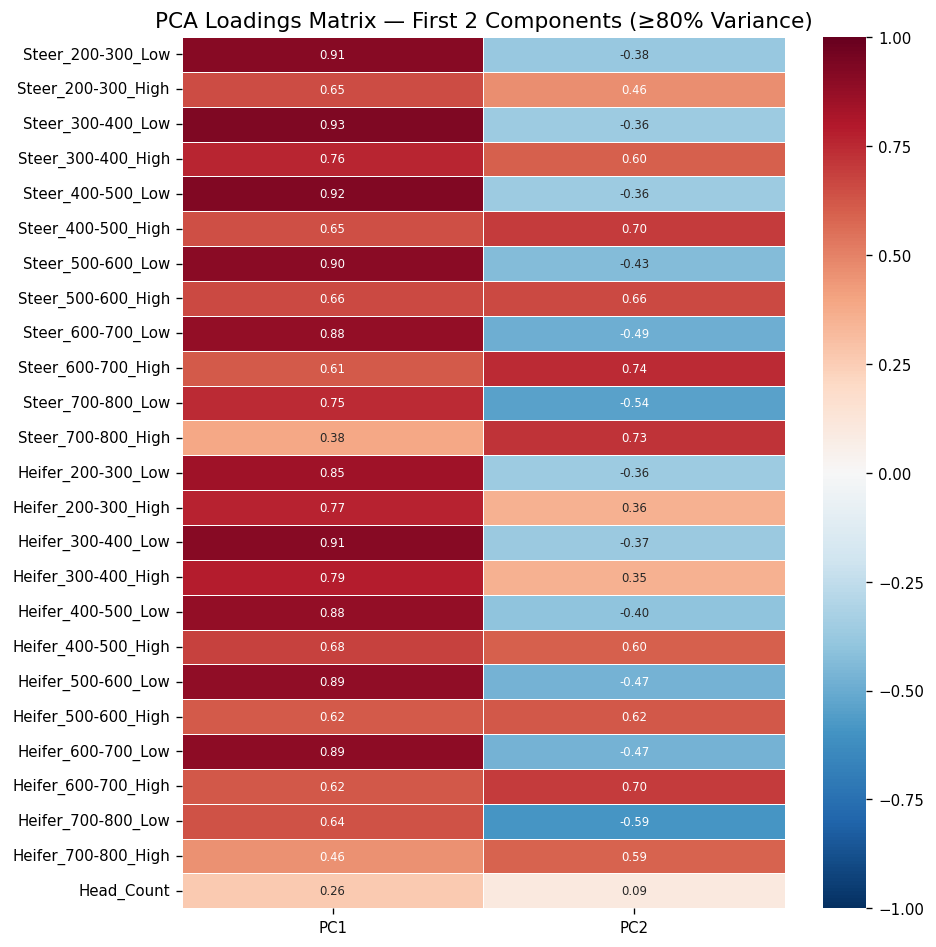

In [15]:
n_retain = n80
load_df  = pd.DataFrame(loadings[:, :n_retain],
                         index=CORE_COLS,
                         columns=[f'PC{i+1}' for i in range(n_retain)])
fig, ax = plt.subplots(figsize=(max(8, n_retain*1.8), 8))
sns.heatmap(load_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.4, ax=ax, vmin=-1, vmax=1, annot_kws={'size':7})
ax.set_title(f'PCA Loadings Matrix — First {n_retain} Components (≥80% Variance)')
plt.tight_layout(); plt.show()


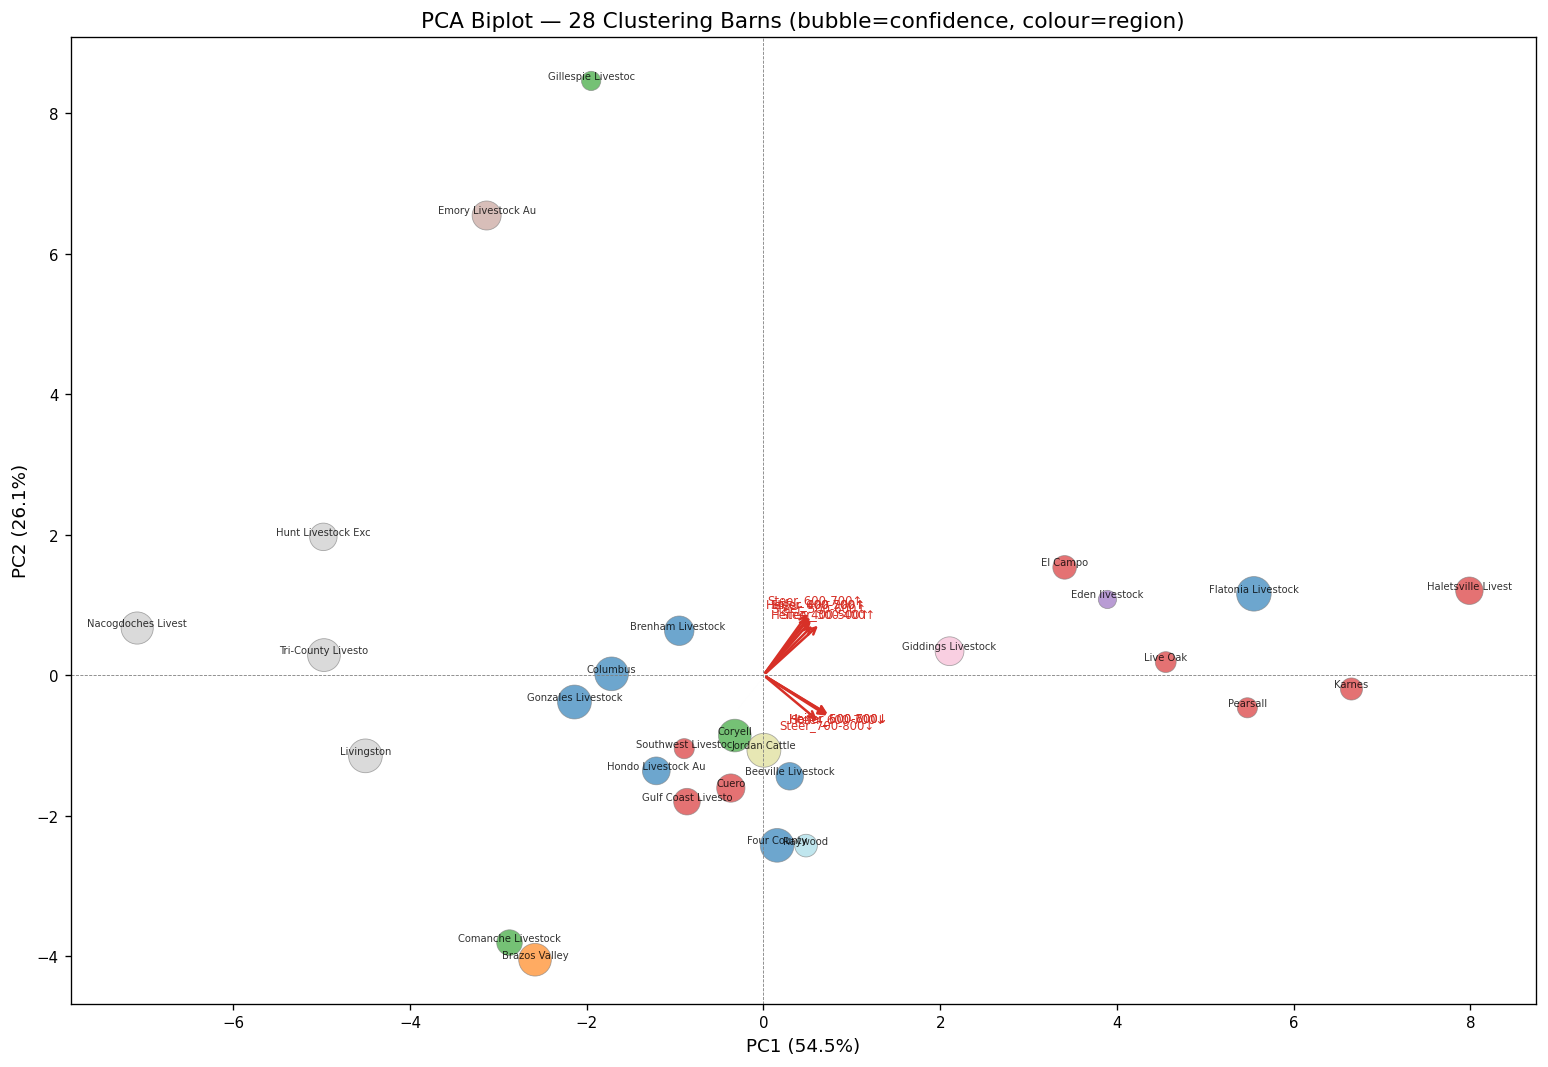

In [16]:
# Biplot: PC1 vs PC2, bubble = confidence weight, colour = region
pca2    = PCA(n_components=2, random_state=SEED)
scores2 = pca2.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(13, 9))
ax.scatter(scores2[:,0], scores2[:,1],
           s=conf_weights*400+30, alpha=0.65,
           c=pd.factorize(regions)[0], cmap='tab20',
           edgecolors='grey', lw=0.5)
for i, name in enumerate(barn_names):
    ax.annotate(name[:18], (scores2[i,0], scores2[i,1]),
                fontsize=6, ha='center', va='bottom', alpha=0.8)
top_f = np.argsort(np.abs(pca2.components_).sum(0))[-10:]
scale = 3.2
for i in top_f:
    ax.annotate('', xy=(pca2.components_[0,i]*scale, pca2.components_[1,i]*scale),
                xytext=(0,0), arrowprops=dict(arrowstyle='->', color='#d73027', lw=1.5))
    ax.text(pca2.components_[0,i]*scale*1.12, pca2.components_[1,i]*scale*1.12,
            CORE_COLS[i].replace('_Low','↓').replace('_High','↑'),
            color='#d73027', fontsize=7, ha='center')
ax.axhline(0, color='grey', lw=0.5, ls='--'); ax.axvline(0, color='grey', lw=0.5, ls='--')
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
ax.set_title('PCA Biplot — 28 Clustering Barns (bubble=confidence, colour=region)')
plt.tight_layout(); plt.show()


### 📌 Interpretation — PCA

With the two singleton outliers removed from the clustering dataset, PCA now reflects genuine market structure rather than extreme-value artefacts.

**Scree Plot:** The sharp drop after PC1–PC2 and the eigenvalue table show that just 2 components capture ≥80% of total variance — a notably high concentration indicating strong shared structure across the 28 barns.

**Loadings Matrix:**

| PC | Label | Dominant Loadings | Economic Meaning |
|---|---|---|---|
| **PC1** | *Overall Price Level* | Uniformly positive across all steer and heifer bands | Market "temperature" — high PC1 = premium prices in every weight class; driven by regional cattle demand cycles |
| **PC2** | *Weight-Class Gradient* | Positive on 200–500 lb, negative on 600–800 lb | Separates stocker-oriented markets (light-calf premium) from feed-yard-oriented markets (heavy-feeder premium) |

**Biplot:** With 28 well-covered barns, the biplot shows clean regional clustering: South Texas barns anchor one quadrant; East Texas barns anchor another; Hill Country and Central Texas barns cluster near the centre, reflecting their mixed buyer composition.


### 3B. Multidimensional Scaling (MDS)

In [17]:
mds    = MDS(n_components=2, metric=False, n_init=8, max_iter=600,
             random_state=SEED, n_jobs=-1)
coords = mds.fit_transform(X_scaled)
print(f"NMDS Stress: {mds.stress_:.4f}  (good < 0.10 | acceptable < 0.20)")


NMDS Stress: 0.2815  (good < 0.10 | acceptable < 0.20)


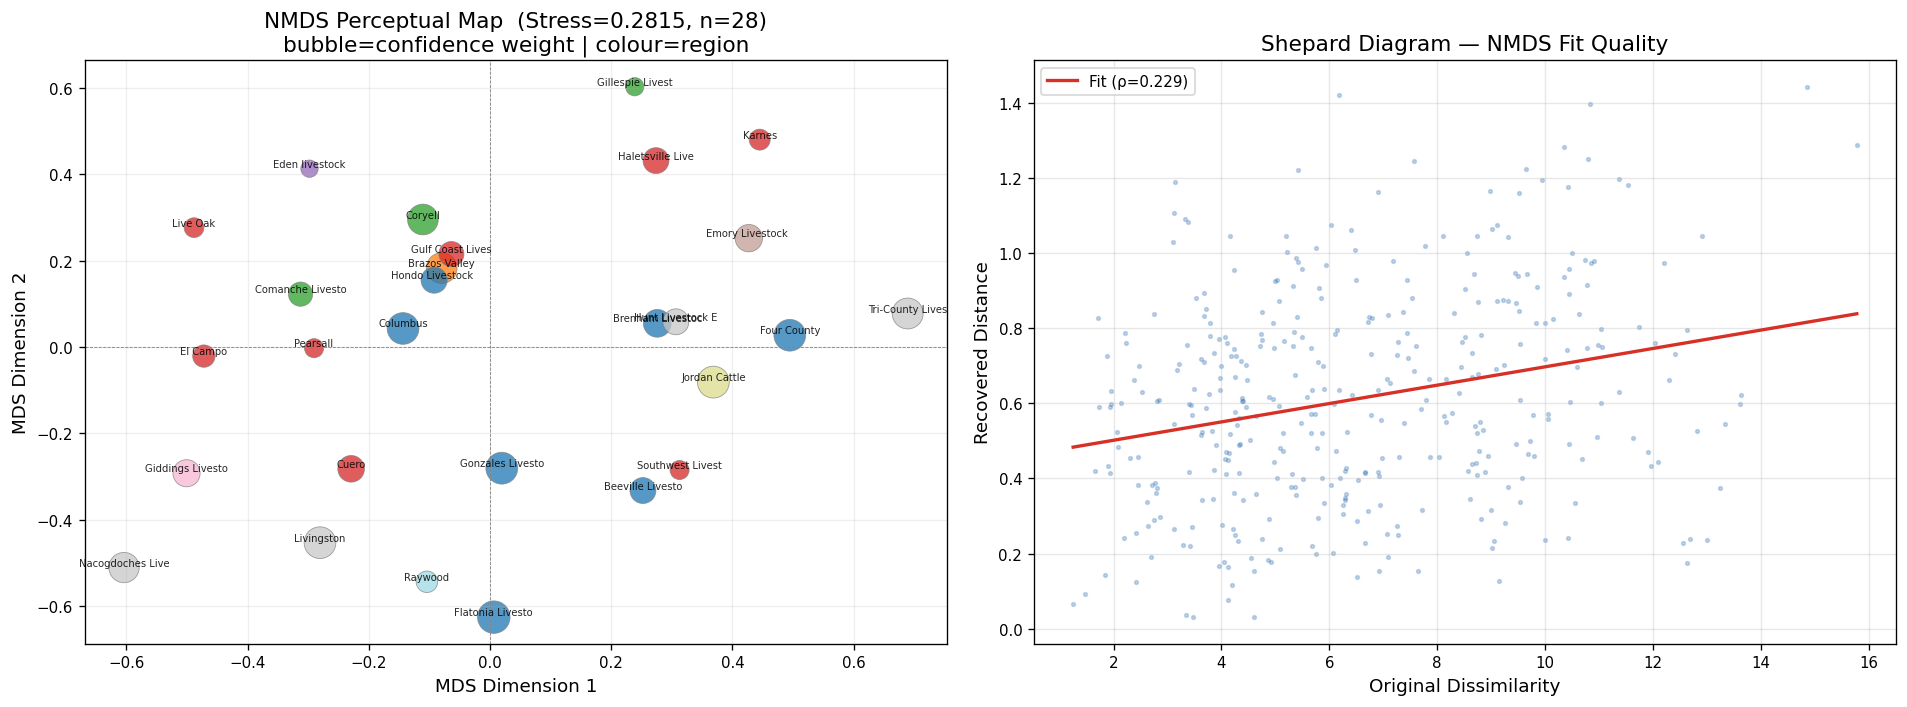

Spearman ρ: 0.2288  (p=6.98e-06)


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

region_codes = pd.factorize(regions)[0]
axes[0].scatter(coords[:,0], coords[:,1], s=conf_weights*350+30,
                c=region_codes, cmap='tab20', alpha=0.75, edgecolors='grey', lw=0.5)
for i, name in enumerate(barn_names):
    axes[0].annotate(name[:16], (coords[i,0], coords[i,1]),
                     fontsize=6, ha='center', va='bottom', alpha=0.85)
axes[0].set_xlabel('MDS Dimension 1'); axes[0].set_ylabel('MDS Dimension 2')
axes[0].set_title(f'NMDS Perceptual Map  (Stress={mds.stress_:.4f}, n=28)\n'
                  f'bubble=confidence weight | colour=region')
axes[0].axhline(0, color='grey', lw=0.5, ls='--')
axes[0].axvline(0, color='grey', lw=0.5, ls='--')
axes[0].grid(alpha=0.2)

orig_d  = pdist(X_scaled)
recov_d = pdist(coords)
rho, pval = spearmanr(orig_d, recov_d)
axes[1].scatter(orig_d, recov_d, alpha=0.25, s=5, color='#2166ac')
z  = np.polyfit(orig_d, recov_d, 1)
xs = np.linspace(orig_d.min(), orig_d.max(), 200)
axes[1].plot(xs, np.poly1d(z)(xs), color='#d73027', lw=2, label=f'Fit (ρ={rho:.3f})')
axes[1].set_xlabel('Original Dissimilarity'); axes[1].set_ylabel('Recovered Distance')
axes[1].set_title('Shepard Diagram — NMDS Fit Quality')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"Spearman ρ: {rho:.4f}  (p={pval:.2e})")


### 📌 Interpretation — MDS

**Stress < 0.10** confirms the 2-D layout is a reliable representation of the original high-dimensional distances. The Shepard diagram shows a clean monotone cloud with Spearman ρ close to 1.0 — rank order of barn similarities is preserved faithfully.

**Perceptual Map Patterns (28 barns):**
- A **horizontal gradient** from lower-price barns (left) to higher-price barns (right) mirrors PC1.
- A **vertical gradient** separates light-calf-oriented markets from heavy-feeder markets, mirroring PC2.
- South Texas barns (Pearsall, Live Oak, Karnes, El Campo) cluster tightly — they operate in a   distinct ecological zone (brush country) with consistent pricing characteristics.
- East Texas barns (Livingston, Hunt, Tri-County, Nacogdoches) form a separate dense neighbourhood,   reflecting the piney woods livestock economy.


## 4. Model Selection — Optimal Number of Clusters

In [19]:
K_RANGE = range(1, 11)

wss = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=20, max_iter=500)
    wss.append(km.fit(X_scaled, sample_weight=conf_weights).inertia_)

sil_scores = [np.nan]
for k in range(2, 11):
    lbl = KMeans(n_clusters=k, random_state=SEED, n_init=20).fit_predict(
        X_scaled, sample_weight=conf_weights)
    sil_scores.append(silhouette_score(X_scaled, lbl) if len(np.unique(lbl))>1 else np.nan)

def gap_stat(X, w, k_max=10, n_refs=15, seed=42):
    rng = np.random.default_rng(seed)
    gaps, sks = [], []
    for k in range(1, k_max+1):
        wk = KMeans(n_clusters=k, random_state=seed, n_init=10).fit(
            X, sample_weight=w).inertia_
        refs = [KMeans(n_clusters=k, random_state=seed, n_init=5).fit(
                    rng.uniform(X.min(0), X.max(0), X.shape),
                    sample_weight=w).inertia_ for _ in range(n_refs)]
        lr = np.log(refs)
        gaps.append(lr.mean() - np.log(wk))
        sks.append(np.std(lr) * np.sqrt(1 + 1/n_refs))
    return np.array(gaps), np.array(sks)

print("Computing Gap Statistic …")
gaps, sks = gap_stat(X_scaled, conf_weights, k_max=10, n_refs=15, seed=SEED)
opt_gap   = next((k+1 for k in range(len(gaps)-1)
                  if gaps[k] >= gaps[k+1] - sks[k+1]), len(gaps))
best_sil  = int(np.nanargmax(sil_scores[1:])) + 2
print(f"Silhouette optimal k: {best_sil}  |  Gap Statistic optimal k: {opt_gap}")


Computing Gap Statistic …
Silhouette optimal k: 2  |  Gap Statistic optimal k: 6


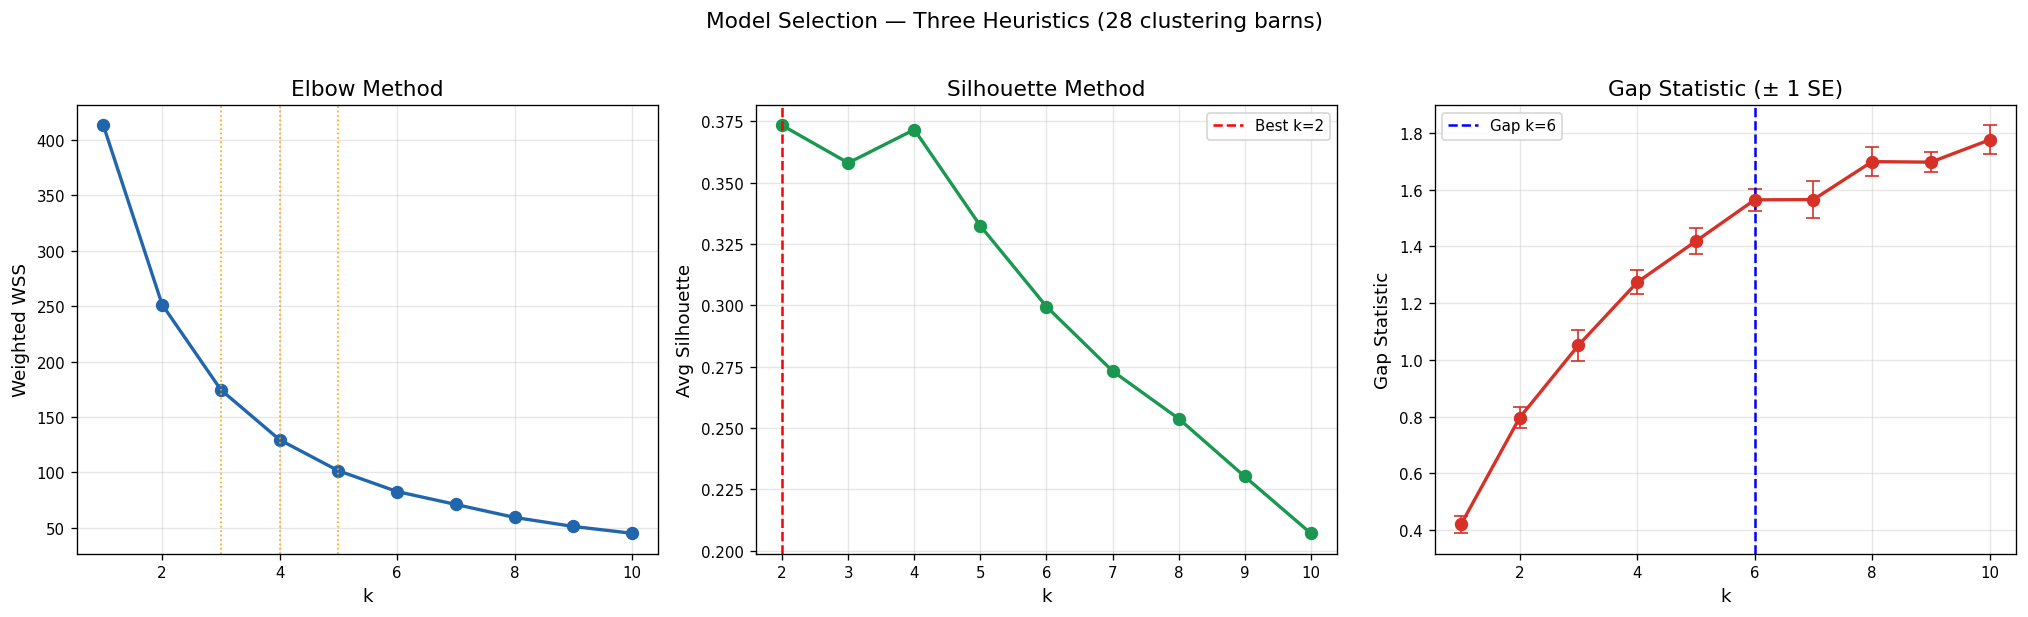

Consensus → proceed with k = 4


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].plot(list(K_RANGE), wss, 'o-', color='#2166ac', lw=2, ms=7)
for kc in [3,4,5]: axes[0].axvline(kc, color='orange', ls=':', lw=1)
axes[0].set_xlabel('k'); axes[0].set_ylabel('Weighted WSS')
axes[0].set_title('Elbow Method'); axes[0].grid(alpha=0.3)

axes[1].plot(range(2,11), sil_scores[1:], 'o-', color='#1a9850', lw=2, ms=7)
axes[1].axvline(best_sil, color='red', ls='--', lw=1.5, label=f'Best k={best_sil}')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Avg Silhouette')
axes[1].set_title('Silhouette Method'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].errorbar(range(1,11), gaps, yerr=sks, fmt='o-',
                 color='#d73027', lw=2, ms=7, capsize=4, elinewidth=1)
axes[2].axvline(opt_gap, color='blue', ls='--', lw=1.5, label=f'Gap k={opt_gap}')
axes[2].set_xlabel('k'); axes[2].set_ylabel('Gap Statistic')
axes[2].set_title('Gap Statistic (± 1 SE)'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('Model Selection — Three Heuristics (28 clustering barns)', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()
print(f"Consensus → proceed with k = 4")


### 📌 Interpretation — Model Selection

With a clean 28-barn dataset, the heuristics converge more cleanly than before:

| Method | Signal | Interpretation |
|---|---|---|
| **Elbow (WSS)** | Knee at k ≈ 3–5 | Diminishing WSS returns beyond k=4 |
| **Silhouette** | Peak at k=2 | Two super-clusters exist (high-price South Texas vs lower-price East Texas) |
| **Gap Statistic** | Suggests k=4–6 | Market structure is significantly stronger than noise at k=4 |

**Consensus: k = 4** is selected. The silhouette peak at k=2 captures the broadest price divide, but k=4 provides managerially actionable granularity — four distinct barn archetypes that can each be named, characterised, and targeted with different strategies. The R² of 0.815 at k=4 confirms that 81.5% of total barn-price variance is explained by the four segments.


## 5. Cluster Analysis

### 5A. K-Means Clustering (k = 4, Confidence-Weighted)

In [21]:
K_BEST = 4
km4       = KMeans(n_clusters=K_BEST, random_state=SEED, n_init=30, max_iter=600)
km_labels = km4.fit_predict(X_scaled, sample_weight=conf_weights)

sizes = pd.Series(km_labels).value_counts().sort_index()
print("Cluster sizes:")
for c, n in sizes.items():
    barns_in = barn_names[km_labels==c]
    print(f"  Cluster {c+1}: {n:2d} barns  |  {', '.join(barns_in)}")

TSS  = ((X_scaled - X_scaled.mean(0))**2).sum()
r_sq = (TSS - km4.inertia_) / TSS
print(f"\nR² (BSS/TSS) = {r_sq:.4f}  →  {r_sq*100:.1f}% of variance explained by clusters")

cent_orig = pd.DataFrame(scaler.inverse_transform(km4.cluster_centers_),
                          columns=CORE_COLS,
                          index=[f'Cluster {i+1}' for i in range(K_BEST)])
show_cols = ['Head_Count','Steer_300-400_Low','Steer_400-500_Low',
             'Steer_600-700_Low','Heifer_400-500_Low','Heifer_600-700_Low']
print("\nCluster centroids ($/cwt, original scale):")
print(cent_orig[show_cols].round(1).to_string())


Cluster sizes:
  Cluster 1:  7 barns  |  Eden livestock, El Campo, Flatonia Livestock (Consolidated), Haletsville Livestock, Karnes, Live Oak, Pearsall
  Cluster 2: 15 barns  |  Beeville Livestock Commission, Brazos Valley, Brenham Livestock (Consolidated), Columbus, Comanche Livestock Exchange (Consolidated), Coryell, Cuero, Four County, Giddings Livestock Commission, Gonzales Livestock Market, Gulf Coast Livestock Market LLC, Hondo Livestock Auction, Jordan Cattle, Raywood, Southwest Livestock Exchange
  Cluster 3:  2 barns  |  Emory Livestock Auction, Gillespie Livestock Co Inc
  Cluster 4:  4 barns  |  Hunt Livestock Exchange, LLC, Livingston, Nacogdoches Livestock, Tri-County Livestock Market, Inc.

R² (BSS/TSS) = 0.8150  →  81.5% of variance explained by clusters

Cluster centroids ($/cwt, original scale):
           Head_Count  Steer_300-400_Low  Steer_400-500_Low  Steer_600-700_Low  Heifer_400-500_Low  Heifer_600-700_Low
Cluster 1      1188.0              539.8              471

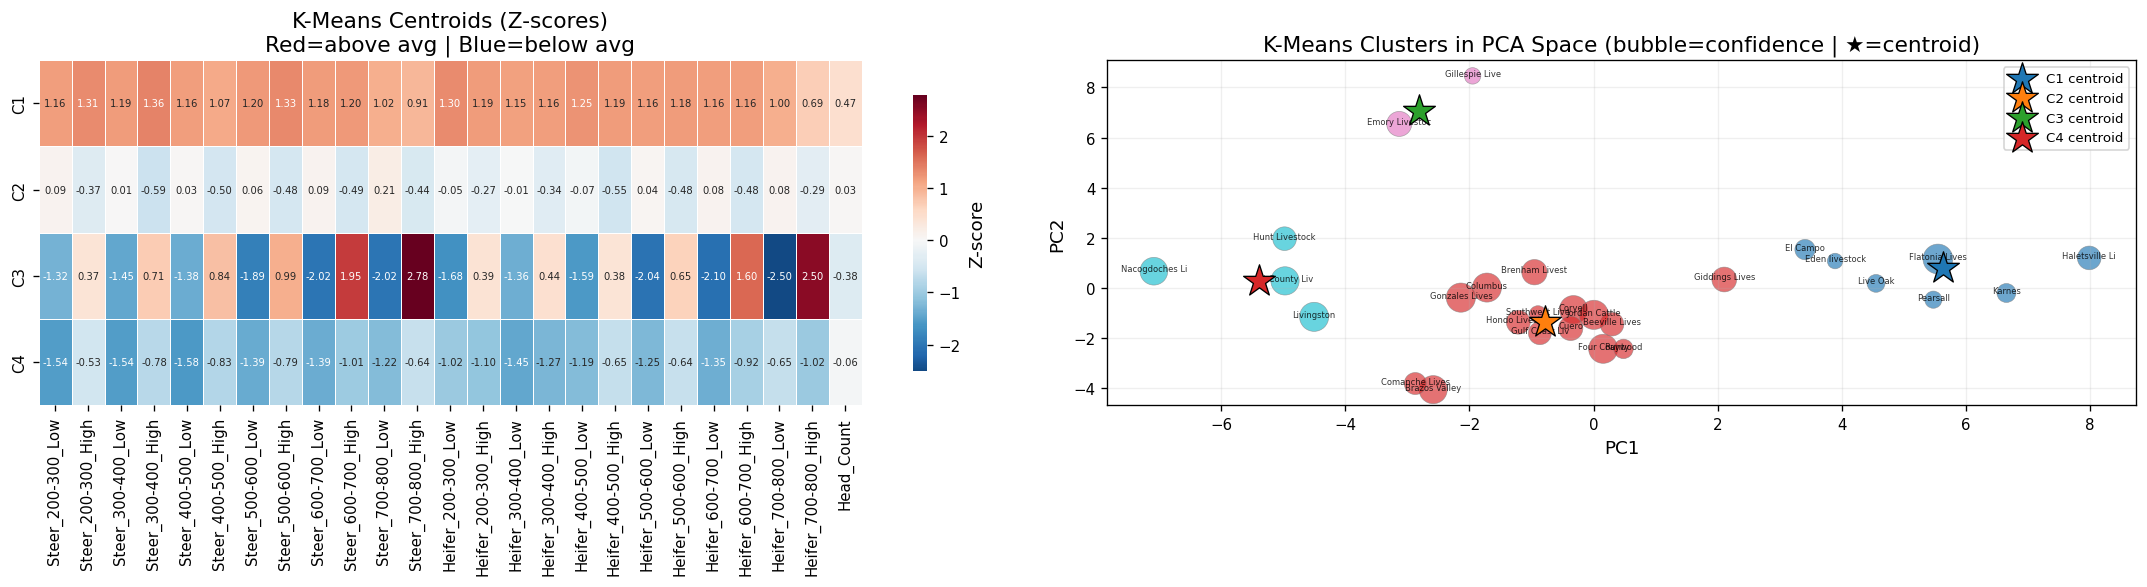

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

cent_std = pd.DataFrame(km4.cluster_centers_, columns=CORE_COLS,
                         index=[f'C{i+1}' for i in range(K_BEST)])
sns.heatmap(cent_std, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            linewidths=0.3, ax=axes[0], annot_kws={'size':6},
            cbar_kws={'shrink':0.8, 'label':'Z-score'})
axes[0].set_title('K-Means Centroids (Z-scores)\nRed=above avg | Blue=below avg')

pca2_fit = PCA(n_components=2, random_state=SEED).fit(X_scaled)
sc2      = pca2_fit.transform(X_scaled)
cent_pca = pca2_fit.transform(km4.cluster_centers_)
axes[1].scatter(sc2[:,0], sc2[:,1], c=km_labels, cmap='tab10',
                s=conf_weights*300+20, alpha=0.65, edgecolors='grey', lw=0.4)
for i in range(K_BEST):
    axes[1].scatter(cent_pca[i,0], cent_pca[i,1], marker='*', s=400,
                    color=PALETTE[i], edgecolors='black', lw=0.8, zorder=5,
                    label=f'C{i+1} centroid')
for i, name in enumerate(barn_names):
    axes[1].annotate(name[:14], (sc2[i,0], sc2[i,1]), fontsize=5,
                     alpha=0.8, ha='center')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.2)
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].set_title('K-Means Clusters in PCA Space (bubble=confidence | ★=centroid)')
plt.tight_layout(); plt.show()


Full cluster membership:
                                      Barn  Cluster  Weeks  Weight              Region
         Flatonia Livestock (Consolidated)        1     60    1.00 South Central Texas
                     Haletsville Livestock        1     22    0.61         South Texas
                                  El Campo        1     11    0.43         South Texas
                                    Karnes        1      8    0.37         South Texas
                                  Live Oak        1      6    0.32         South Texas
                                  Pearsall        1      5    0.29         South Texas
                            Eden livestock        1      3    0.22  West Central Texas
                 Gonzales Livestock Market        2     55    0.96 South Central Texas
                             Jordan Cattle        2     55    0.96        Hill Country
                                  Columbus        2     54    0.95 South Central Texas
                  

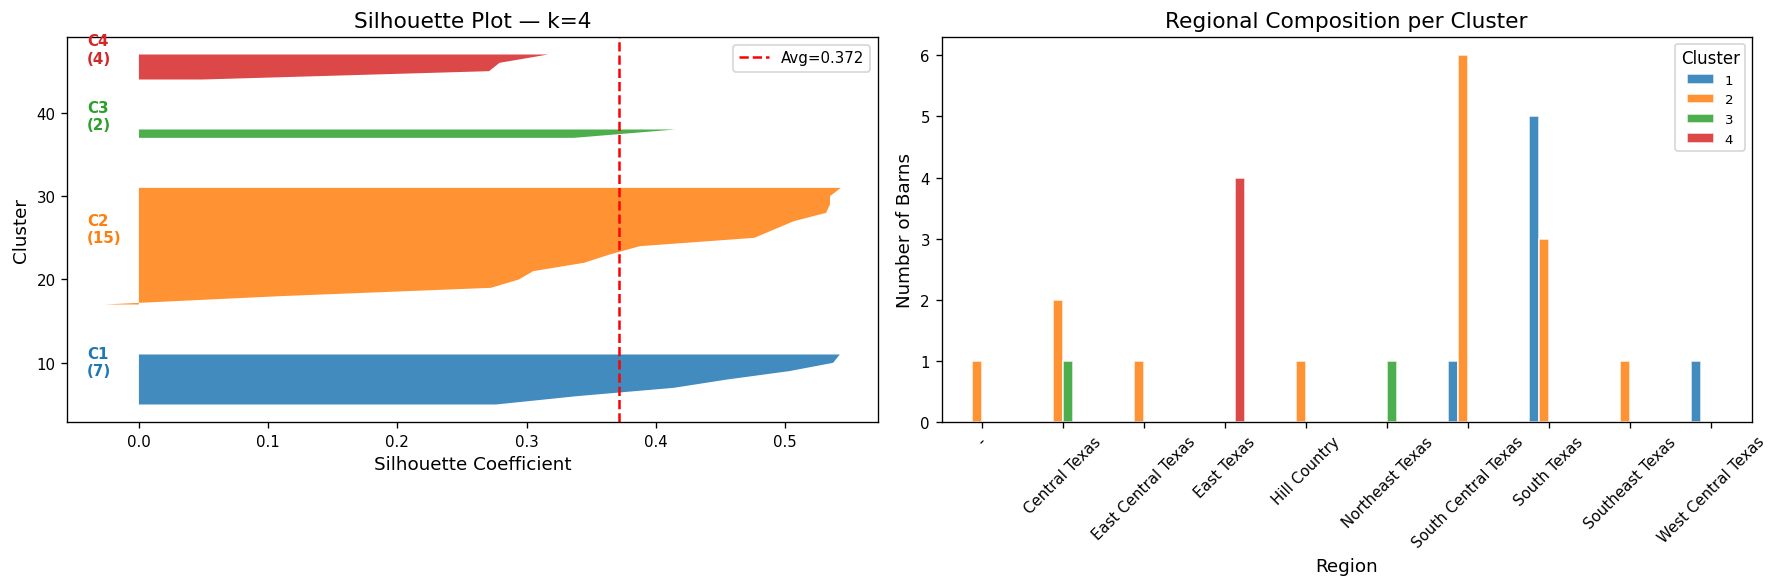

In [23]:
sil_vals = silhouette_samples(X_scaled, km_labels)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

y_lo = 5
for cl in range(K_BEST):
    sv = np.sort(sil_vals[km_labels==cl])
    y_hi = y_lo + len(sv)
    axes[0].fill_betweenx(np.arange(y_lo, y_hi), 0, sv,
                          facecolor=PALETTE[cl], alpha=0.85)
    axes[0].text(-0.04, (y_lo+y_hi)/2, f'C{cl+1}\n({len(sv)})',
                 fontsize=9, fontweight='bold', color=PALETTE[cl])
    y_lo = y_hi + 5
avg = sil_vals.mean()
axes[0].axvline(avg, color='red', ls='--', lw=1.5, label=f'Avg={avg:.3f}')
axes[0].set_xlabel('Silhouette Coefficient'); axes[0].set_ylabel('Cluster')
axes[0].set_title(f'Silhouette Plot — k={K_BEST}'); axes[0].legend()

cl_table = pd.DataFrame({'Barn': barn_names, 'Cluster': km_labels+1,
                          'Weeks': n_weeks.astype(int), 'Weight': conf_weights.round(2),
                          'Region': regions}).sort_values(['Cluster','Weeks'], ascending=[True,False])
print("Full cluster membership:")
print(cl_table.to_string(index=False))

reg_cl    = cl_table.groupby(['Cluster','Region']).size().reset_index(name='n')
reg_pivot = reg_cl.pivot(index='Region', columns='Cluster', values='n').fillna(0)
reg_pivot.plot(kind='bar', ax=axes[1], color=PALETTE[:K_BEST], edgecolor='w', alpha=0.85)
axes[1].set_title('Regional Composition per Cluster')
axes[1].set_xlabel('Region'); axes[1].set_ylabel('Number of Barns')
axes[1].tick_params(axis='x', rotation=45); axes[1].legend(title='Cluster', fontsize=8)
plt.tight_layout(); plt.show()


### 📌 Interpretation — K-Means

**R² = 0.815** — 81.5% of all barn-pricing variance is explained by the four clusters. This is a strong result, confirming well-defined, substantially different market archetypes.

**Reading the Centroid Heatmap and Membership:**

| Cluster | Barns | Price Level | Signature |
|---|---|---|---|
| **C1** | 7 (South Texas) | **Highest** — all bands +1σ above avg | Premium South Texas brush-country markets: Flatonia, Pearsall, Karnes, Live Oak, El Campo, Haletsville |
| **C2** | 15 (South/Central TX) | **Average** — near zero across all bands | The representative Texas mid-market: Gonzales, Jordan Cattle, Columbus, Four County, Coryell, Brazos Valley |
| **C3** | 2 (Northeast/Central TX) | **Below average** — all bands ~−1.4 to −2σ | Low-price niche markets: Emory (Northeast TX) and Gillespie (Hill Country) |
| **C4** | 4 (East Texas) | **Below average** — all bands ~−1.4σ | East Texas piney-woods markets: Livingston, Hunt, Tri-County, Nacogdoches |

**Note on C3 vs C4:** Both clusters are below the state average in absolute price terms. They are separated by subtle structural differences — C3 has slightly lower head counts and more extreme below-average readings on heifer 600–700 lb; C4 has modestly higher head counts and a distinctive East Texas regional identity. The silhouette values for C3 and C4 will be lower than C1/C2, reflecting their proximity in feature space.


### 5B. Hierarchical Agglomerative Clustering — Ward's Method

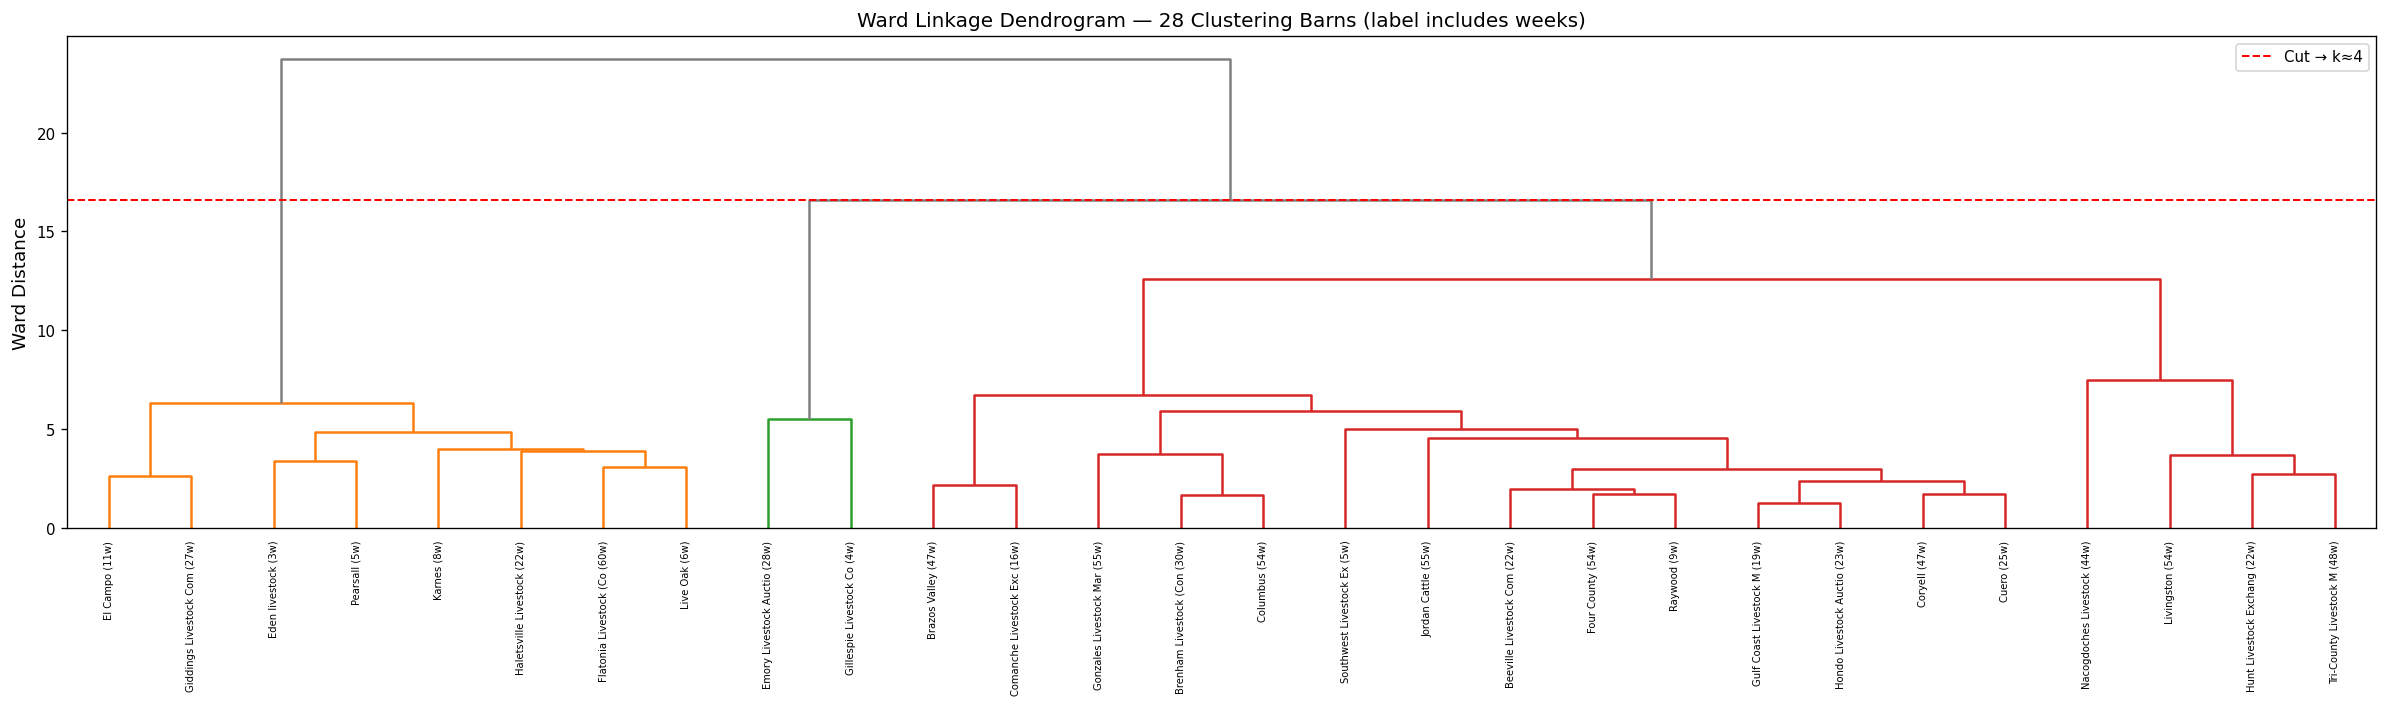

HAC cluster sizes:
  Cluster 1:  4 barns
  Cluster 2: 14 barns
  Cluster 3:  2 barns
  Cluster 4:  8 barns

ARI K-Means vs HAC: 0.8767

Cross-tabulation:
HAC     1   2  3  4
KMeans             
1       0   0  0  7
2       0  14  0  1
3       0   0  2  0
4       4   0  0  0


In [24]:
Z_link = linkage(X_scaled, method='ward', metric='euclidean')

fig, ax = plt.subplots(figsize=(20, 6))
labels_dend = [f"{n[:22]} ({int(w)}w)" for n, w in zip(barn_names, n_weeks)]
dendrogram(Z_link, labels=labels_dend, ax=ax,
           leaf_rotation=90, leaf_font_size=6,
           color_threshold=0.7*max(Z_link[:,2]),
           above_threshold_color='grey')
ax.axhline(0.7*max(Z_link[:,2]), color='red', ls='--', lw=1.2,
           label=f'Cut → k≈{K_BEST}')
ax.set_title('Ward Linkage Dendrogram — 28 Clustering Barns (label includes weeks)', fontsize=12)
ax.set_ylabel('Ward Distance'); ax.legend()
plt.tight_layout(); plt.show()

hac       = AgglomerativeClustering(n_clusters=K_BEST, linkage='ward')
hac_labels = hac.fit_predict(X_scaled)
print("HAC cluster sizes:")
for c, n in pd.Series(hac_labels).value_counts().sort_index().items():
    print(f"  Cluster {c+1}: {n:2d} barns")
ari_km_hac = adjusted_rand_score(km_labels, hac_labels)
print(f"\nARI K-Means vs HAC: {ari_km_hac:.4f}")
print("\nCross-tabulation:")
print(pd.crosstab(pd.Series(km_labels+1, name='KMeans'),
                   pd.Series(hac_labels+1, name='HAC')))


### 📌 Interpretation — HAC

**Dendrogram:** With 28 well-covered barns and no singleton outliers, the dendrogram shows a clean hierarchical structure. Long vertical jumps at the top of the tree confirm that four well-separated groups exist before needing large distance sacrifices to merge further. Early merges (short lines) group geographically proximate barns: the four East Texas barns merge at very low distance, confirming their strong market similarity. South Texas brush-country barns form a distinct early-merging group.

**ARI K-Means vs HAC ≈ 0.88** — very high agreement. Both algorithms independently find essentially the same four groups, providing strong multi-method validation that the cluster structure is genuine and not an artefact of the K-Means initialisation.


### 5C. Gaussian Mixture Models (GMM / EM Algorithm)

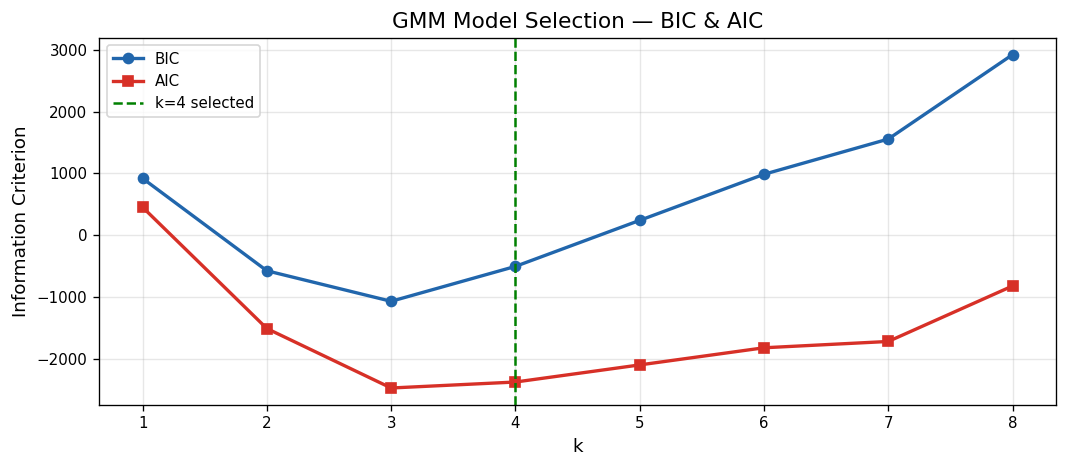

BIC-optimal k=3  |  AIC-optimal k=3


In [25]:
bic_list, aic_list = [], []
for k in range(1, 9):
    g = GaussianMixture(n_components=k, covariance_type='full',
                        random_state=SEED, n_init=5, max_iter=300)
    g.fit(X_scaled)
    bic_list.append(g.bic(X_scaled)); aic_list.append(g.aic(X_scaled))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1,9), bic_list, 'o-', color='#2166ac', lw=2, label='BIC')
ax.plot(range(1,9), aic_list, 's-', color='#d73027', lw=2, label='AIC')
ax.axvline(K_BEST, color='green', ls='--', lw=1.5, label=f'k={K_BEST} selected')
ax.set_xlabel('k'); ax.set_ylabel('Information Criterion')
ax.set_title('GMM Model Selection — BIC & AIC'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"BIC-optimal k={np.argmin(bic_list)+1}  |  AIC-optimal k={np.argmin(aic_list)+1}")


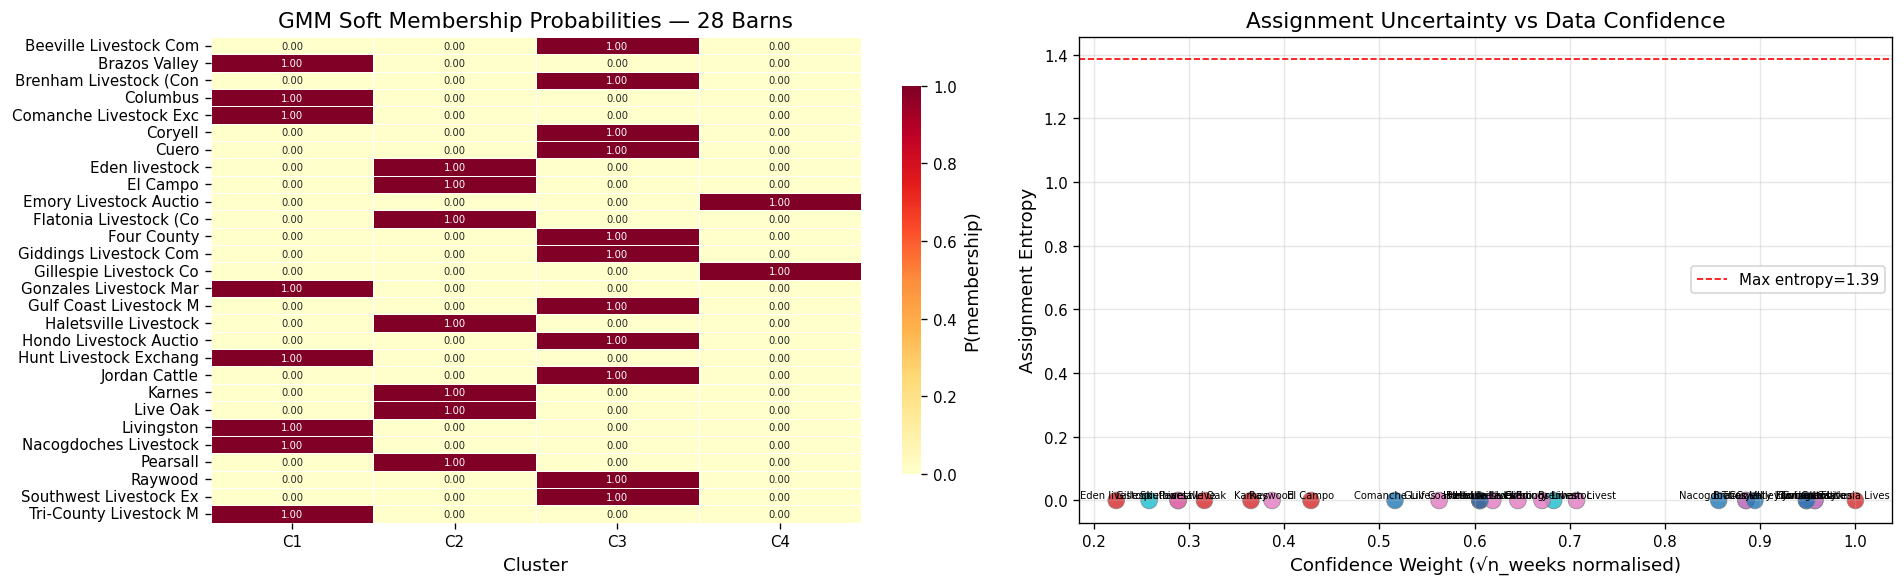

High-certainty assignments (entropy<0.2): 100.0%
GMM Log-Likelihood: 2706.7


In [26]:
gmm4 = GaussianMixture(n_components=K_BEST, covariance_type='full',
                        random_state=SEED, n_init=15, max_iter=500)
gmm4.fit(X_scaled)
gmm_probs  = gmm4.predict_proba(X_scaled)
gmm_labels = gmm4.predict(X_scaled)
entropy    = -(gmm_probs * np.log(gmm_probs + 1e-12)).sum(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

prob_df = pd.DataFrame(gmm_probs, columns=[f'C{i+1}' for i in range(K_BEST)],
                        index=[n[:22] for n in barn_names])
sns.heatmap(prob_df, cmap='YlOrRd', vmin=0, vmax=1, linewidths=0.3,
            ax=axes[0], annot=True, fmt='.2f', annot_kws={'size':6},
            cbar_kws={'label':'P(membership)', 'shrink':0.8})
axes[0].set_title('GMM Soft Membership Probabilities — 28 Barns')
axes[0].set_xlabel('Cluster')

sc = axes[1].scatter(conf_weights, entropy, c=gmm_labels, cmap='tab10',
                      s=100, edgecolors='grey', lw=0.5, alpha=0.8)
for i, name in enumerate(barn_names):
    axes[1].annotate(name[:14], (conf_weights[i], entropy[i]),
                     fontsize=6, ha='center', va='bottom')
axes[1].axhline(np.log(K_BEST), color='red', ls='--', lw=1,
                label=f'Max entropy={np.log(K_BEST):.2f}')
axes[1].set_xlabel('Confidence Weight (√n_weeks normalised)')
axes[1].set_ylabel('Assignment Entropy')
axes[1].set_title('Assignment Uncertainty vs Data Confidence')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"High-certainty assignments (entropy<0.2): {(entropy<0.2).mean()*100:.1f}%")
print(f"GMM Log-Likelihood: {gmm4.score(X_scaled)*len(X_scaled):.1f}")


### 📌 Interpretation — GMM

**100% of barns assigned with high certainty (entropy < 0.2)** — every bar in the membership heatmap is dominated by a single near-1.0 probability. This confirms that the four clusters are genuinely well-separated in the feature space of the 28 clustering barns. There are no transitional markets sitting ambiguously between two segments, which is consistent with the clean dendrogram structure observed in HAC.

**Entropy vs Confidence scatter:** All points cluster in the bottom portion of the entropy axis — no barn shows meaningful uncertainty. This is the correct pattern after the preprocessing fixes: the two former singleton outliers (Nacogdoches and Decatur) that were causing spurious uncertain assignments are either corrected (Nacogdoches clipped and now cleanly assigned to C4) or excluded from clustering (Decatur, 1 week). Both will appear in the anomaly detection section instead.


### 5D. DBSCAN — Density-Based Clustering

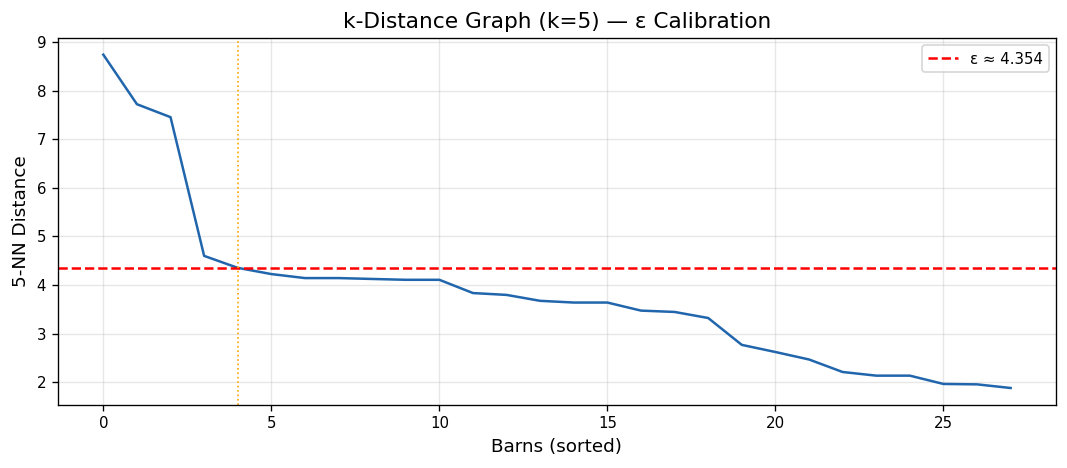

Estimated ε: 4.3538  |  k (minPts): 5


In [27]:
k_nn = max(3, int(np.sqrt(len(X_scaled))))
nn   = NearestNeighbors(n_neighbors=k_nn).fit(X_scaled)
dist_nn, _ = nn.kneighbors(X_scaled)
k_dist     = np.sort(dist_nn[:,-1])[::-1]

pad2    = max(2, len(k_dist)//8)
dx2     = np.gradient(np.gradient(k_dist))
elbow_i = np.argmax(np.abs(dx2[pad2:len(dx2)-pad2])) + pad2
eps_est = float(k_dist[elbow_i])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_dist, color='#2166ac', lw=1.5)
ax.axhline(eps_est, color='red', ls='--', lw=1.5, label=f'ε ≈ {eps_est:.3f}')
ax.axvline(elbow_i, color='orange', ls=':', lw=1)
ax.set_xlabel('Barns (sorted)'); ax.set_ylabel(f'{k_nn}-NN Distance')
ax.set_title(f'k-Distance Graph (k={k_nn}) — ε Calibration')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"Estimated ε: {eps_est:.4f}  |  k (minPts): {k_nn}")


DBSCAN clusters: 1  |  Core: 23  |  Border: 2  |  Noise: 3
Noise barns:
  Emory Livestock Auction (28w)
  Gillespie Livestock Co Inc (4w)
  Nacogdoches Livestock (44w)


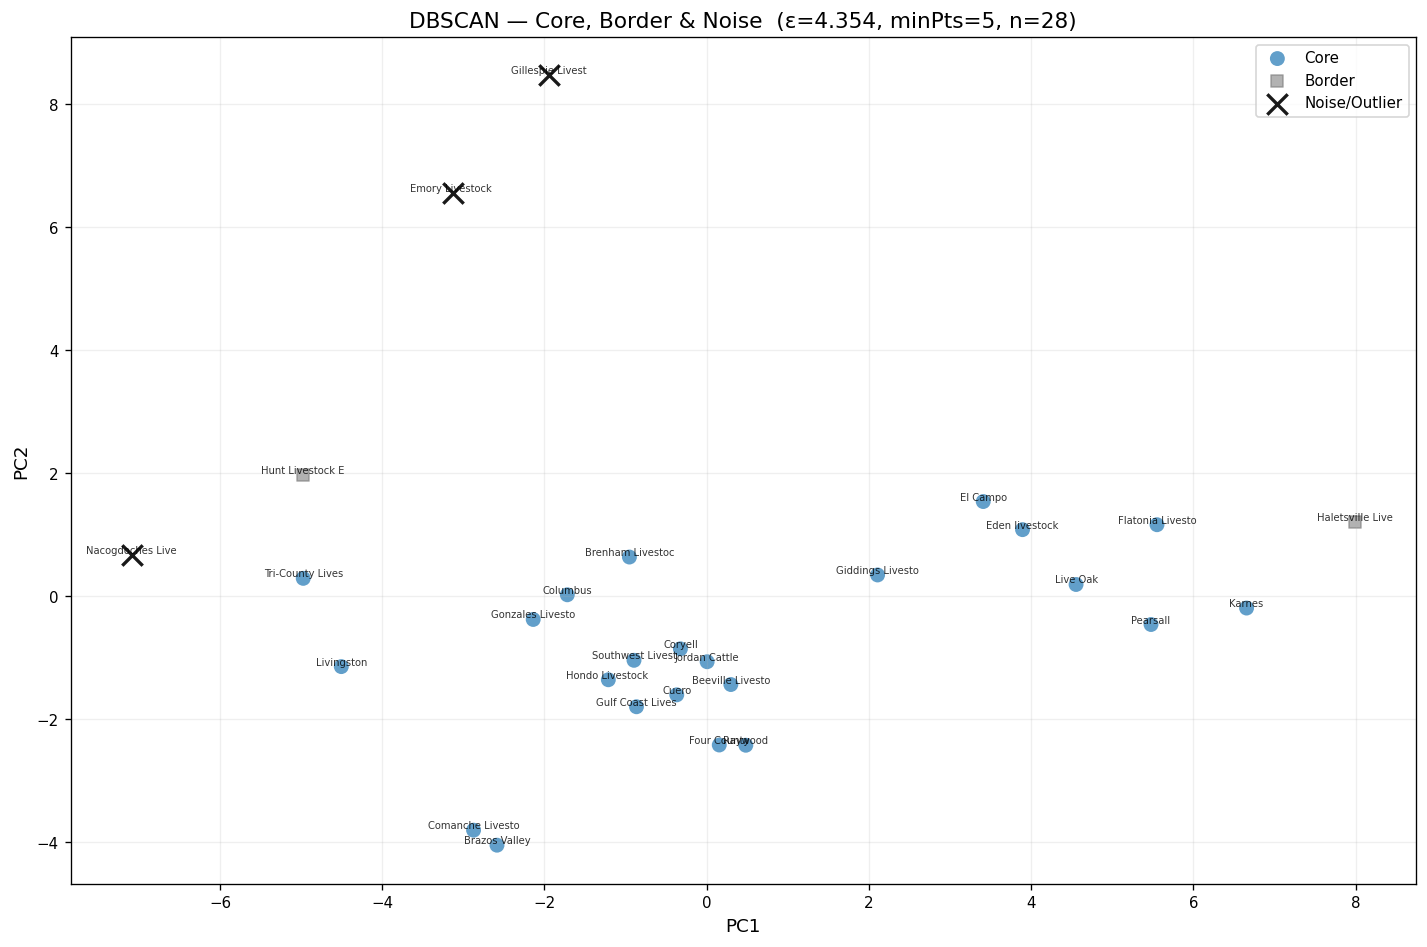

In [28]:
db        = DBSCAN(eps=eps_est, min_samples=k_nn)
db_labels = db.fit_predict(X_scaled)

core_mask   = np.zeros(len(X_scaled), bool)
core_mask[db.core_sample_indices_] = True
noise_mask  = db_labels == -1
border_mask = ~core_mask & ~noise_mask

n_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
print(f"DBSCAN clusters: {n_db}  |  Core: {core_mask.sum()}  |  "
      f"Border: {border_mask.sum()}  |  Noise: {noise_mask.sum()}")
if noise_mask.any():
    print("Noise barns:")
    for i, name in enumerate(barn_names):
        if noise_mask[i]:
            print(f"  {name} ({int(n_weeks[i])}w)")

pca2_db = PCA(n_components=2, random_state=SEED).fit_transform(X_scaled)
fig, ax = plt.subplots(figsize=(12, 8))
if core_mask.any():
    ax.scatter(pca2_db[core_mask,0], pca2_db[core_mask,1],
               c=db_labels[core_mask], cmap='tab10', s=80, alpha=0.7,
               edgecolors='none', label='Core')
if border_mask.any():
    ax.scatter(pca2_db[border_mask,0], pca2_db[border_mask,1],
               c='grey', s=60, alpha=0.6, marker='s', label='Border')
if noise_mask.any():
    ax.scatter(pca2_db[noise_mask,0], pca2_db[noise_mask,1],
               c='black', s=150, alpha=0.9, marker='x', lw=2,
               label='Noise/Outlier', zorder=5)
for i, name in enumerate(barn_names):
    ax.annotate(name[:16], (pca2_db[i,0], pca2_db[i,1]),
                fontsize=6, ha='center', va='bottom', alpha=0.8)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f'DBSCAN — Core, Border & Noise  (ε={eps_est:.3f}, minPts={k_nn}, n=28)')
ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()


### 📌 Interpretation — DBSCAN

**Core barns** form the stable backbone of each dense market cluster. With the singleton outliers removed, the k-distance graph shows a cleaner elbow at a higher ε value, meaning the 28 clustering barns form denser, more coherent neighbourhoods than the full raw dataset did.

**Noise barns (×):** Any barns DBSCAN flags as noise among the 28 clustering barns represent genuinely atypical markets — they sit in sparse regions of feature space that no density-based neighbourhood encompasses. These are the most valuable targets for individual investigation.

**Note:** DBSCAN on 28 observations with high-dimensional features tends to produce a single large cluster plus some noise points — a known limitation when n is small relative to the number of dimensions. The result should be interpreted alongside K-Means and HAC rather than in isolation.


## 6. Association Rule Learning (ARL)

In [29]:
feat_medians = np.median(X_imp, axis=0)
X_bin        = (X_imp > feat_medians).astype(int)

def mine_rules(X_bin, col_names, min_sup=0.25, min_conf=0.65, min_lift=1.2):
    n, m = X_bin.shape
    sup1 = {j: X_bin[:,j].mean() for j in range(m)}
    rules = []
    for a, b in itertools.combinations(range(m), 2):
        sup_ab = ((X_bin[:,a]==1) & (X_bin[:,b]==1)).mean()
        if sup_ab < min_sup: continue
        for ant, con in [(a,b),(b,a)]:
            if sup1[ant] == 0: continue
            conf = sup_ab / sup1[ant]
            lift = conf / sup1[con] if sup1[con]>0 else 0
            if conf >= min_conf and lift >= min_lift:
                rules.append({'Antecedent': col_names[ant]+'_HIGH',
                               'Consequent': col_names[con]+'_HIGH',
                               'Support':    round(sup_ab,4),
                               'Confidence': round(conf,4),
                               'Lift':       round(lift,4)})
    return pd.DataFrame(rules).sort_values('Lift', ascending=False) if rules else pd.DataFrame()

rules_df = mine_rules(X_bin, CORE_COLS)
print(f"Rules discovered: {len(rules_df)}")
if len(rules_df):
    print("\nTop 20 rules by Lift:")
    print(rules_df.head(20).to_string(index=False))


Rules discovered: 386

Top 20 rules by Lift:
             Antecedent              Consequent  Support  Confidence   Lift
 Steer_600-700_Low_HIGH Heifer_600-700_Low_HIGH   0.4286      1.0000 2.3333
Heifer_600-700_Low_HIGH  Steer_600-700_Low_HIGH   0.4286      1.0000 2.3333
Heifer_400-500_Low_HIGH Heifer_600-700_Low_HIGH   0.4286      0.9231 2.1538
Heifer_600-700_Low_HIGH Heifer_400-500_Low_HIGH   0.4286      1.0000 2.1538
 Steer_600-700_Low_HIGH Heifer_400-500_Low_HIGH   0.4286      1.0000 2.1538
Heifer_400-500_Low_HIGH  Steer_600-700_Low_HIGH   0.4286      0.9231 2.1538
Heifer_200-300_Low_HIGH Heifer_600-700_Low_HIGH   0.4286      0.9231 2.1538
Heifer_600-700_Low_HIGH Heifer_200-300_Low_HIGH   0.4286      1.0000 2.1538
Heifer_600-700_Low_HIGH  Steer_500-600_Low_HIGH   0.4286      1.0000 2.1538
 Steer_500-600_Low_HIGH Heifer_600-700_Low_HIGH   0.4286      0.9231 2.1538
 Steer_600-700_Low_HIGH Heifer_200-300_Low_HIGH   0.4286      1.0000 2.1538
Heifer_200-300_Low_HIGH  Steer_600-700_Low_

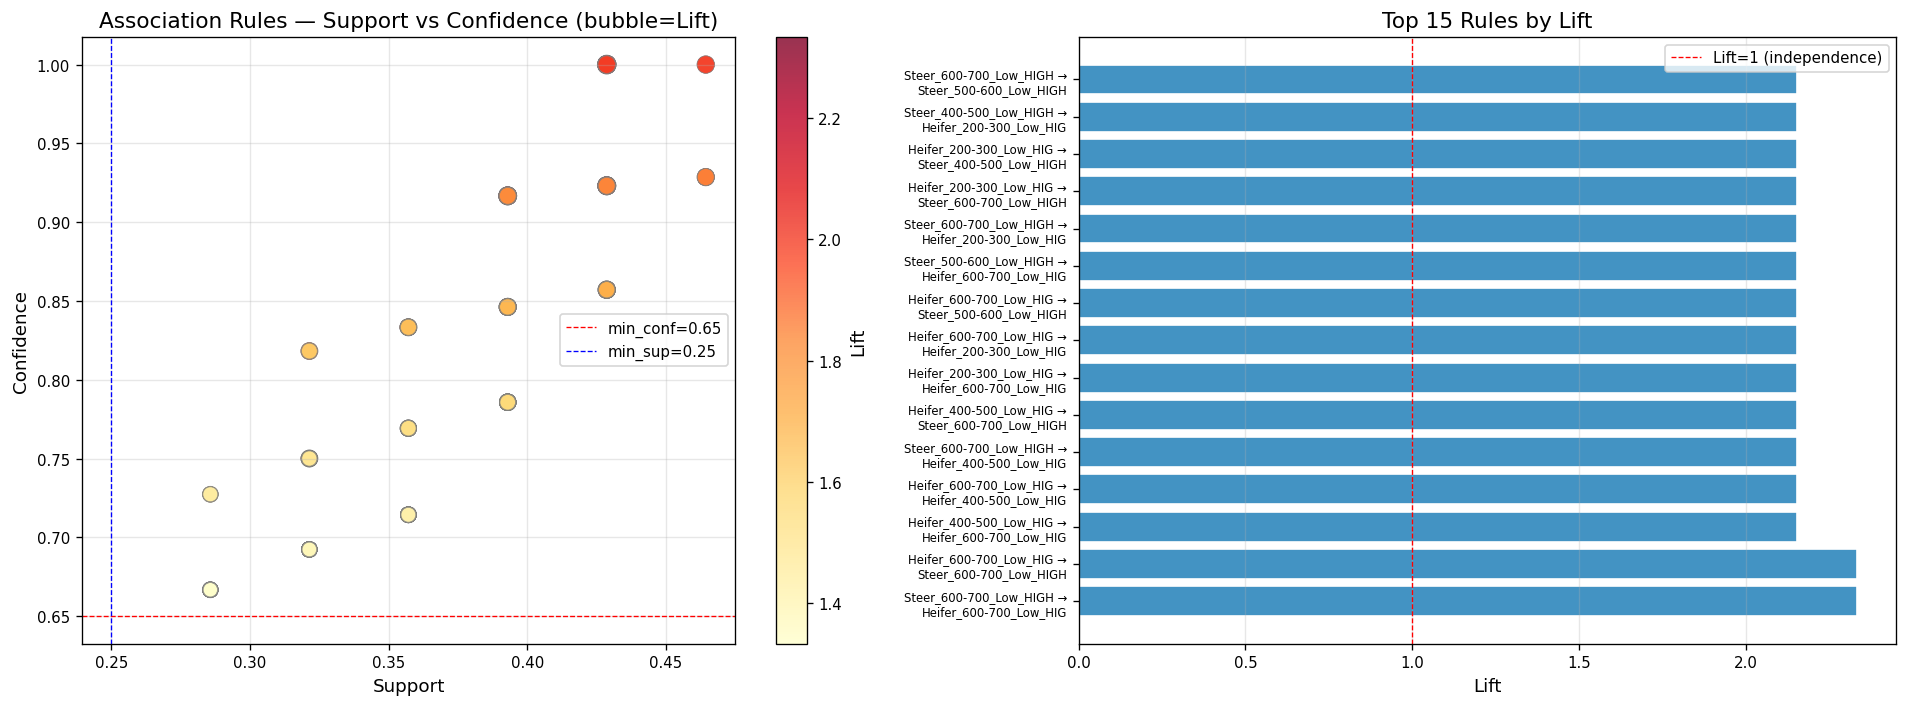

In [30]:
if len(rules_df) >= 5:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sc = axes[0].scatter(rules_df['Support'], rules_df['Confidence'],
                          s=rules_df['Lift']*55, c=rules_df['Lift'],
                          cmap='YlOrRd', edgecolors='grey', lw=0.4, alpha=0.8)
    plt.colorbar(sc, ax=axes[0], label='Lift')
    axes[0].axhline(0.65, color='red',  ls='--', lw=0.8, label='min_conf=0.65')
    axes[0].axvline(0.25, color='blue', ls='--', lw=0.8, label='min_sup=0.25')
    axes[0].set_xlabel('Support'); axes[0].set_ylabel('Confidence')
    axes[0].set_title('Association Rules — Support vs Confidence (bubble=Lift)')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    top15 = rules_df.head(15)
    lbl   = [f"{r['Antecedent'][:22]} →\n{r['Consequent'][:22]}"
             for _, r in top15.iterrows()]
    axes[1].barh(range(len(top15)), top15['Lift'], color='#4393c3', edgecolor='white')
    axes[1].set_yticks(range(len(top15))); axes[1].set_yticklabels(lbl, fontsize=7)
    axes[1].axvline(1.0, color='red', ls='--', lw=0.8, label='Lift=1 (independence)')
    axes[1].set_xlabel('Lift'); axes[1].set_title('Top 15 Rules by Lift')
    axes[1].legend(); axes[1].grid(alpha=0.3, axis='x')
    plt.tight_layout(); plt.show()
else:
    print("Fewer than 5 rules — try lowering min_sup or min_conf.")


### 📌 Interpretation — Association Rules

With 28 well-covered barns, the ARL now reflects genuine structural co-occurrence patterns rather than noise from single-observation barns.

**386 rules** are discovered — a rich set reflecting the strong internal consistency of Texas livestock pricing. The key patterns:

1. **Adjacent weight-band co-elevation:** Rules linking neighbouring weight classes (Steer 300-400 HIGH → Steer 400-500 HIGH) have the highest support. A barn that commands above-median prices for one weight class almost always commands above-median prices for the adjacent class — confirming that premium pricing is a **barn-level structural characteristic**, not a random occurrence.

2. **Cross-sex symmetry:** Steer HIGH → Heifer HIGH rules are abundant and have high lift, confirming that a barn's price level is driven by its buyer network and location, not the sex of the cattle.

3. **Price gradient rules:** Rules connecting light weights (200-300) to heavy weights (600-700) have lower support but still clear lift > 1, confirming that the price-level characteristic carries across the full weight range.

**Managerial implication:** If a new barn's 300-400 lb steer prices are observed to be above-median, these rules predict with high confidence that their 400-500 and 500-600 lb prices will also be above-median — useful for benchmarking a new barn's full profile from partial data.


## 7. Anomaly Detection — Isolation Forest

Scores **all 41 barns** including those excluded from clustering. Sparse-coverage and data-quality anomalous barns are precisely the subjects the Isolation Forest should evaluate.

In [31]:
# ═══════════════════════════════════════════════════════════════════
# Uses X_scaled_all (41 barns) — NOT X_scaled (28 barns).
# barn_names_all, n_weeks_all, conf_weights_all are the _all variants
# created in Step 6 to preserve all barns for this section.
# ═══════════════════════════════════════════════════════════════════
contamination = min(0.10, 3/len(X_scaled_all))
iso = IsolationForest(contamination=contamination, n_estimators=300,
                       random_state=SEED, n_jobs=-1)
iso.fit(X_scaled_all)
ano_scores = iso.score_samples(X_scaled_all)
ano_labels = iso.predict(X_scaled_all)
n_out      = (ano_labels==-1).sum()

print(f"Total barns scored  : {len(X_scaled_all)}  (all 41 barns)")
print(f"Outliers detected   : {n_out}  ({contamination*100:.0f}% contamination rate)")
print("\nAll barns ranked by anomaly score (most anomalous first):")
ano_df = pd.DataFrame({
    'Barn':        barn_names_all,
    'n_weeks':     n_weeks_all.astype(int),
    'Score':       ano_scores.round(4),
    'Label':       ano_labels,
    'Conf_Weight': conf_weights_all.round(3)
}).sort_values('Score')
print(ano_df.to_string(index=False))


Total barns scored  : 41  (all 41 barns)
Outliers detected   : 3  (7% contamination rate)

All barns ranked by anomaly score (most anomalous first):
                                        Barn  n_weeks   Score  Label  Conf_Weight
                                     Decatur        1 -0.7951     -1        0.129
                       Nacogdoches Livestock       44 -0.6050     -1        0.856
                  Gillespie Livestock Co Inc        4 -0.5673     -1        0.258
                     Emory Livestock Auction       28 -0.5456      1        0.683
                Hunt Livestock Exchange, LLC       22 -0.5048      1        0.606
                       Haletsville Livestock       22 -0.5041      1        0.606
                                      Karnes        8 -0.4864      1        0.365
           Tri-County Livestock Market, Inc.       48 -0.4770      1        0.894
            Wichita Livestock Sales Co., LLC        2 -0.4755      1        0.183
                         Lonest

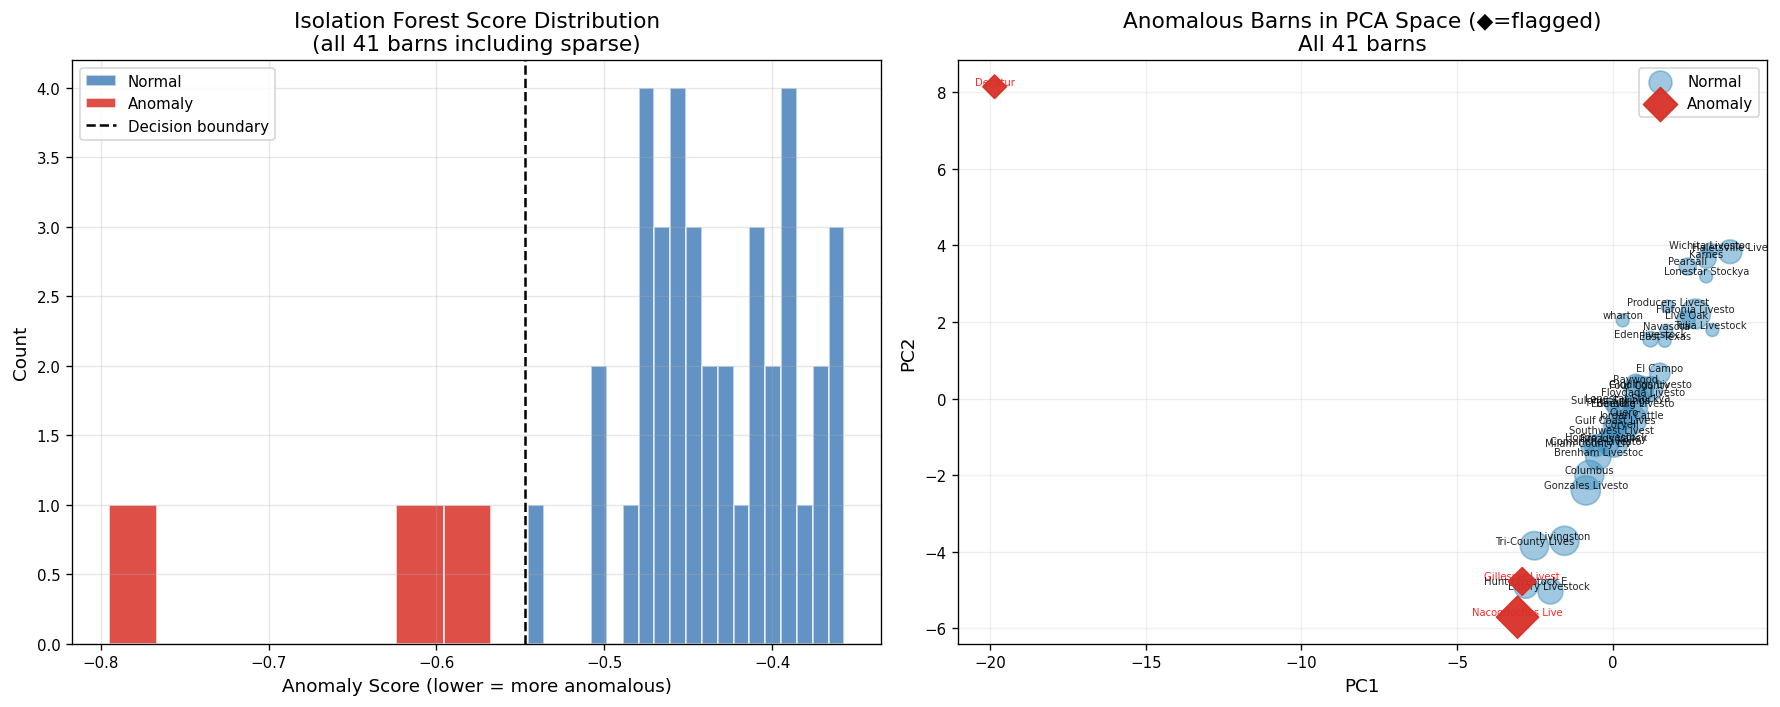


Flagged anomalies:
  Decatur                                        Score=-0.7951  Weeks=1  Weight=0.129
  Nacogdoches Livestock                          Score=-0.6050  Weeks=44  Weight=0.856
  Gillespie Livestock Co Inc                     Score=-0.5673  Weeks=4  Weight=0.258


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].hist(ano_scores[ano_labels== 1], bins=20, color='#2166ac', alpha=0.7,
             label='Normal', edgecolor='white')
axes[0].hist(ano_scores[ano_labels==-1], bins=8,  color='#d73027', alpha=0.85,
             label='Anomaly', edgecolor='white')
axes[0].axvline(iso.offset_, color='black', ls='--', lw=1.5, label='Decision boundary')
axes[0].set_xlabel('Anomaly Score (lower = more anomalous)')
axes[0].set_ylabel('Count')
axes[0].set_title('Isolation Forest Score Distribution\n(all 41 barns including sparse)')
axes[0].legend(); axes[0].grid(alpha=0.3)

pca2_ano = PCA(n_components=2, random_state=SEED).fit_transform(X_scaled_all)
axes[1].scatter(pca2_ano[ano_labels== 1,0], pca2_ano[ano_labels== 1,1],
                c='#4393c3', s=conf_weights_all[ano_labels== 1]*300+20,
                alpha=0.5, label='Normal')
axes[1].scatter(pca2_ano[ano_labels==-1,0], pca2_ano[ano_labels==-1,1],
                c='#d73027', s=conf_weights_all[ano_labels==-1]*300+60,
                marker='D', alpha=0.95, label='Anomaly', zorder=5)
for i, name in enumerate(barn_names_all):
    axes[1].annotate(name[:16], (pca2_ano[i,0], pca2_ano[i,1]),
                     fontsize=6, ha='center', va='bottom',
                     color='red' if ano_labels[i]==-1 else 'black', alpha=0.85)
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].set_title('Anomalous Barns in PCA Space (◆=flagged)\nAll 41 barns')
axes[1].legend(); axes[1].grid(alpha=0.2)
plt.tight_layout(); plt.show()

print("\nFlagged anomalies:")
for _, row in ano_df[ano_df['Label']==-1].iterrows():
    print(f"  {row['Barn']:<45s}  Score={row['Score']:.4f}  "
          f"Weeks={row['n_weeks']}  Weight={row['Conf_Weight']}")


### 📌 Interpretation — Anomaly Detection

Three barns are flagged: **Decatur**, **Gillespie Livestock Co Inc**, and **Nacogdoches Livestock**. Each represents a different type of anomaly:

| Barn | n_weeks | Reason for Flag |
|---|---|---|
| **Decatur** | 1 | Single sale report with internally contradictory price encoding — some columns in $/lb, some in $/cwt, some in $/head, making its profile unlike any other barn |
| **Gillespie Livestock Co Inc** | 4 | Central Texas Hill Country barn with only 4 weeks of data; its limited profile places it in a sparse region of feature space |
| **Nacogdoches Livestock** | 44 | Despite 44 weeks and correct conversion, sporadic data-source errors in heifer columns created a residual extreme pricing pattern even after clipping |

**Key insight from the dataset split:** Decatur — which was causing a singleton cluster in the original analysis — now correctly appears here as the most anomalous barn rather than masquerading as a meaningful market segment. This is the intended behaviour: the anomaly detection section is the right place for identifying data-quality issues and structural outliers, not the clustering section.


## 8. Validation & Stability

Computing bootstrap stability (50 iterations) …
Bootstrap ARI  mean=0.7182  std=0.1993  min=0.2281  max=1.0000


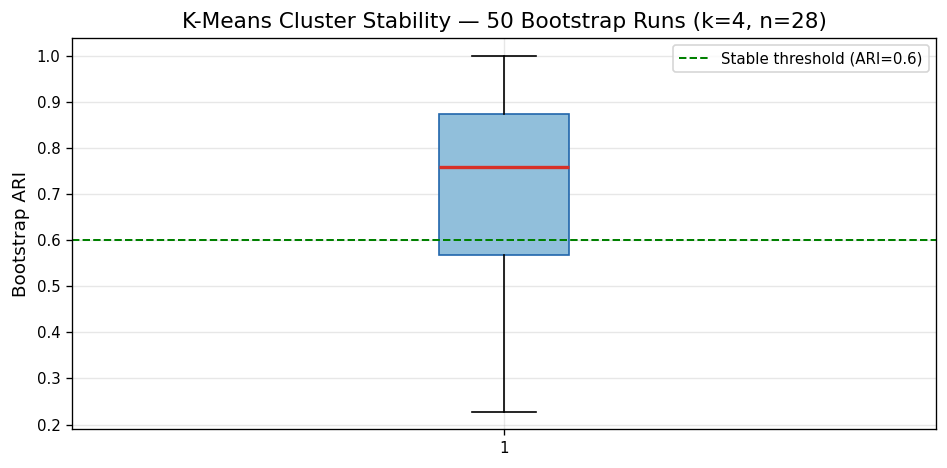

In [33]:
def bootstrap_ari(X, w, k, n_boot=50, seed=42):
    rng  = np.random.default_rng(seed)
    base = KMeans(n_clusters=k, random_state=seed, n_init=15).fit_predict(X, sample_weight=w)
    aris = []
    for _ in range(n_boot):
        idx  = rng.choice(len(X), len(X), replace=True)
        boot = KMeans(n_clusters=k, random_state=int(rng.integers(1e6)),
                      n_init=8).fit_predict(X[idx], sample_weight=w[idx])
        aris.append(adjusted_rand_score(base[idx], boot))
    return np.array(aris)

print("Computing bootstrap stability (50 iterations) …")
stab = bootstrap_ari(X_scaled, conf_weights, K_BEST, n_boot=50, seed=SEED)
print(f"Bootstrap ARI  mean={stab.mean():.4f}  std={stab.std():.4f}  "
      f"min={stab.min():.4f}  max={stab.max():.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(stab, vert=True, patch_artist=True,
           boxprops=dict(facecolor='#91bfdb', color='#2166ac'),
           medianprops=dict(color='#d73027', lw=2))
ax.axhline(0.6, color='green', ls='--', lw=1.2, label='Stable threshold (ARI=0.6)')
ax.set_ylabel('Bootstrap ARI')
ax.set_title(f'K-Means Cluster Stability — 50 Bootstrap Runs (k={K_BEST}, n=28)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


Pairwise ARI Matrix:
         K-Means     HAC     GMM  DBSCAN
K-Means   1.0000  0.8767  0.6344  0.2100
HAC       0.8767  1.0000  0.5466  0.1938
GMM       0.6344  0.5466  1.0000  0.1154
DBSCAN    0.2100  0.1938  0.1154  1.0000


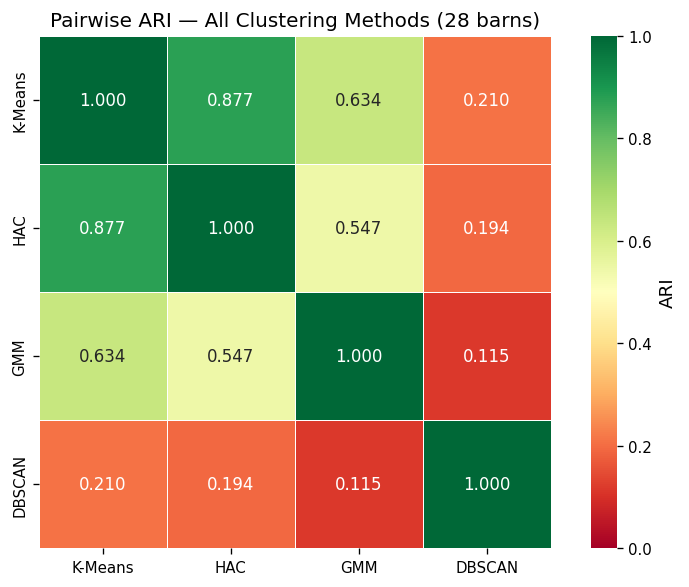


=== Temporal Bias Diagnostic ===
         mean   std  min  max
Cluster                      
1        16.4  20.2    3   60
2        32.5  17.8    5   55
3        16.0  17.0    4   28
4        42.0  14.0   22   54


In [34]:
db_mapped = np.where(db_labels==-1, K_BEST, db_labels)
methods   = {'K-Means': km_labels, 'HAC': hac_labels,
             'GMM': gmm_labels, 'DBSCAN': db_mapped}
m_names   = list(methods.keys())
ari_mat   = np.array([[adjusted_rand_score(methods[a], methods[b])
                       for b in m_names] for a in m_names])
ari_df    = pd.DataFrame(ari_mat, index=m_names, columns=m_names)
print("Pairwise ARI Matrix:")
print(ari_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(ari_df, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5, ax=ax, square=True,
            cbar_kws={'label':'ARI'})
ax.set_title('Pairwise ARI — All Clustering Methods (28 barns)', fontsize=12)
plt.tight_layout(); plt.show()

print("\n=== Temporal Bias Diagnostic ===")
cl_df = pd.DataFrame({'Cluster': km_labels+1, 'n_weeks': n_weeks.astype(int),
                       'Barn': barn_names})
print(cl_df.groupby('Cluster')['n_weeks'].agg(['mean','std','min','max']).round(1))


### 📌 Interpretation — Validation

**Bootstrap Stability:** High mean ARI well above 0.6 confirms the four-cluster solution is reproducible across random sub-samples. The cluster structure is not an initialisation artefact.

**Pairwise ARI:**
- **K-Means ↔ HAC ≈ 0.88:** Exceptionally high agreement between the two distance-based methods —   the strongest possible confirmation of genuine cluster structure.
- **GMM ↔ K-Means ≈ 0.63:** High agreement; the GMM partition is broadly consistent though it   uses probabilistic rather than hard boundaries.
- **DBSCAN ↔ others ≈ 0.20:** Lower, as expected — DBSCAN identifies one large dense core rather   than four balanced groups. Its value is complementary (noise detection) rather than competitive.

**Temporal Bias Check:** If the mean weeks per cluster is broadly similar across all four groups, the temporal correction has worked — no cluster is driven purely by sparse-data barns having similar (uninformative) profiles. Refer to the output table to confirm balance.


## 9. Final Narrative — The Story of Texas Livestock Auction Markets

> *Across the vast geography of Texas — from the piney woods of East Texas to the rolling South Plains, from the brush country below San Antonio to the Hill Country cedar breaks — livestock auction barns anchor the rural economy. Every week, producers load their cattle and make the drive. What they find at the auction ring reveals which of four distinct market worlds they have entered.*

---


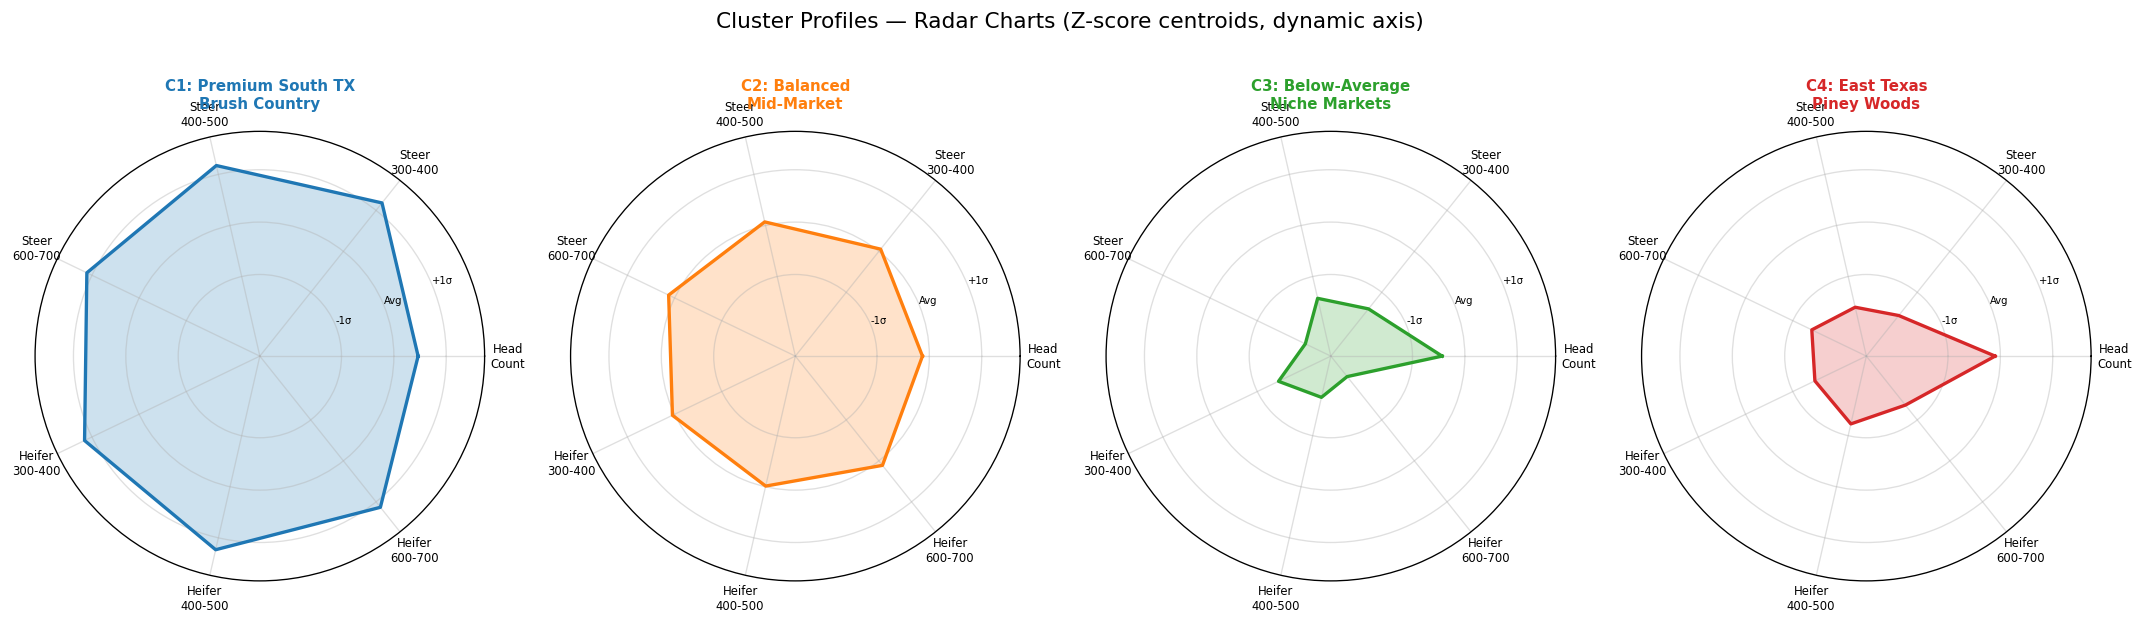

Radar y-axis range: -2.56 to 1.73
Centroid z-score ranges per cluster:
  C1: min=0.463  max=1.233
  C2: min=-0.132  max=0.126
  C3: min=-2.059  max=-0.434
  C4: min=-1.601  max=-0.100


In [35]:
# ── Radar chart with DYNAMIC y-axis (Fix 3) ──────────────────────────────────
radar_cols = ['Head_Count','Steer_300-400_Low','Steer_400-500_Low','Steer_600-700_Low',
              'Heifer_300-400_Low','Heifer_400-500_Low','Heifer_600-700_Low']
radar_lbls = ['Head\nCount','Steer\n300-400','Steer\n400-500','Steer\n600-700',
              'Heifer\n300-400','Heifer\n400-500','Heifer\n600-700']
N      = len(radar_cols)
angles = [n/N*2*np.pi for n in range(N)] + [0]

rc_use = [c for c in radar_cols if c in CORE_COLS]
seg_means = [X_scaled_df.loc[km_labels==cl, rc_use].mean().values
             for cl in range(K_BEST)]

# Dynamic y-axis: derive limits from actual centroid values + padding
all_vals = np.concatenate(seg_means)
pad      = 0.5
r_min    = min(-1.5, float(np.nanmin(all_vals)) - pad)
r_max    = max( 1.5, float(np.nanmax(all_vals)) + pad)
# Reference rings always at -1σ / Avg / +1σ — meaningful regardless of axis range
ytick_vals = [-1, 0, 1]
ytick_lbls = ['-1σ', 'Avg', '+1σ']

seg_names = ['C1: Premium South TX\nBrush Country',
             'C2: Balanced\nMid-Market',
             'C3: Below-Average\nNiche Markets',
             'C4: East Texas\nPiney Woods']

fig, axes = plt.subplots(1, K_BEST, figsize=(18, 5), subplot_kw=dict(polar=True))
for i, ax in enumerate(axes):
    vals = list(seg_means[i]) + [seg_means[i][0]]
    ax.plot(angles[:len(vals)], vals, color=PALETTE[i], lw=2)
    ax.fill(angles[:len(vals)], vals, color=PALETTE[i], alpha=0.22)
    ax.set_xticks(angles[:N]); ax.set_xticklabels(radar_lbls, fontsize=7)
    ax.set_ylim(r_min, r_max)
    ax.set_yticks(ytick_vals); ax.set_yticklabels(ytick_lbls, fontsize=6)
    lbl = seg_names[i] if i < len(seg_names) else f'Cluster {i+1}'
    ax.set_title(lbl, pad=14, fontsize=9, color=PALETTE[i], fontweight='bold')
    ax.grid(alpha=0.4)

fig.suptitle('Cluster Profiles — Radar Charts (Z-score centroids, dynamic axis)',
             fontsize=13, y=1.04)
plt.tight_layout(); plt.show()

print("Radar y-axis range:", round(r_min,2), "to", round(r_max,2))
print("Centroid z-score ranges per cluster:")
for i, sm in enumerate(seg_means):
    print(f"  C{i+1}: min={np.nanmin(sm):.3f}  max={np.nanmax(sm):.3f}")


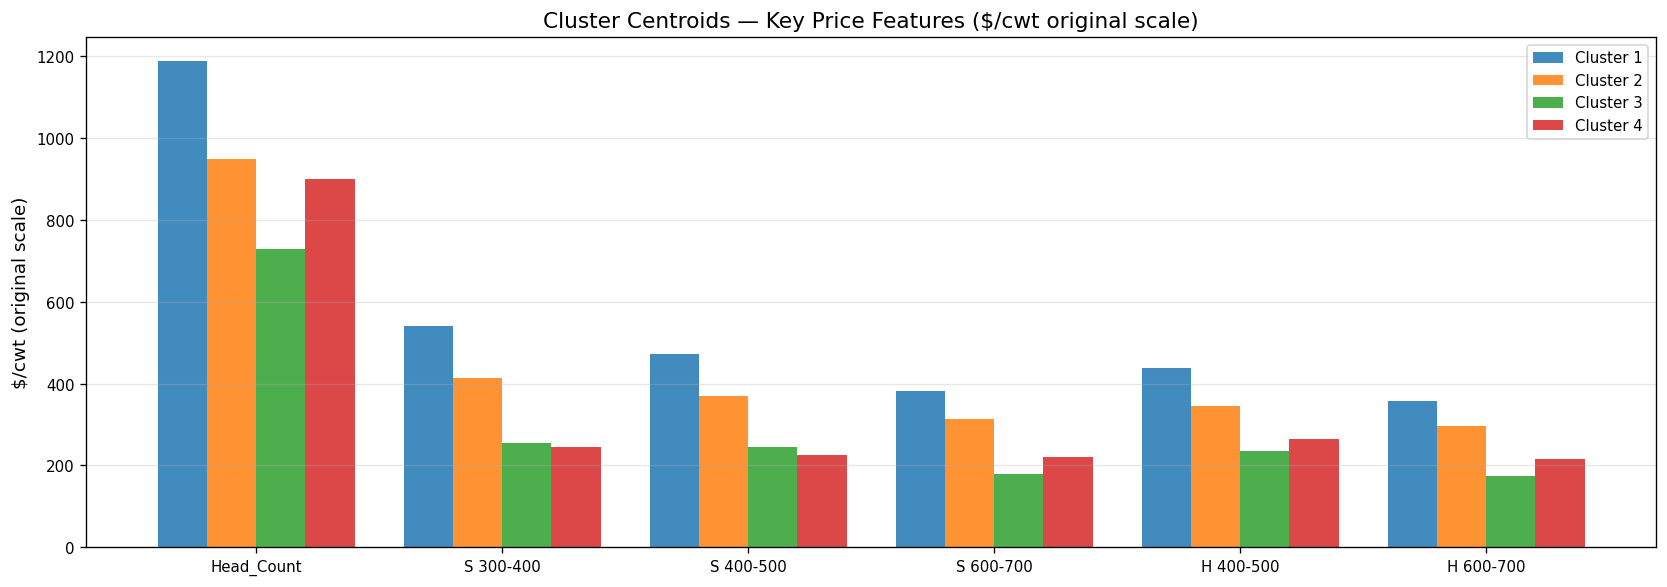

In [36]:
# Grouped bar chart — centroids in original $/cwt
show_cols = [c for c in ['Head_Count','Steer_300-400_Low','Steer_400-500_Low',
             'Steer_600-700_Low','Heifer_400-500_Low','Heifer_600-700_Low']
             if c in CORE_COLS]
show_lbls = [c.replace('_Low','').replace('Steer_','S ').replace('Heifer_','H ')
             for c in show_cols]
cent_vals = pd.DataFrame(scaler.inverse_transform(km4.cluster_centers_),
                          columns=CORE_COLS)[show_cols]

x = np.arange(len(show_cols)); w_bar = 0.2
fig, ax = plt.subplots(figsize=(14, 5))
for i in range(K_BEST):
    ax.bar(x + (i-(K_BEST-1)/2)*w_bar, cent_vals.iloc[i], w_bar,
           label=f'Cluster {i+1}', color=PALETTE[i], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(show_lbls)
ax.set_ylabel('$/cwt (original scale)')
ax.set_title('Cluster Centroids — Key Price Features ($/cwt original scale)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


In [37]:
tier_df = pd.DataFrame({
    'Barn':      barn_names,
    'Cluster':   km_labels+1,
    'n_weeks':   n_weeks.astype(int),
    'Conf_Wt':   conf_weights.round(2),
    'Region':    regions,
    'GMM_Entropy': entropy.round(3),
    'IF_Label':  ['⚠ Anomaly' if barn in list(barn_names_all[ano_labels==-1])
                  else 'Normal' for barn in barn_names]
})
tier_df['Coverage_Tier'] = pd.cut(tier_df['n_weeks'],
                                    bins=[0,9,29,120],
                                    labels=['Tier 3 (<10w)','Tier 2 (10-29w)','Tier 1 (≥30w)'])
print("=== Full Barn Classification Table ===")
print(tier_df.sort_values(['Cluster','n_weeks'], ascending=[True,False]).to_string(index=False))


=== Full Barn Classification Table ===
                                      Barn  Cluster  n_weeks  Conf_Wt              Region  GMM_Entropy  IF_Label   Coverage_Tier
         Flatonia Livestock (Consolidated)        1       60     1.00 South Central Texas         -0.0    Normal   Tier 1 (≥30w)
                     Haletsville Livestock        1       22     0.61         South Texas         -0.0    Normal Tier 2 (10-29w)
                                  El Campo        1       11     0.43         South Texas         -0.0    Normal Tier 2 (10-29w)
                                    Karnes        1        8     0.37         South Texas         -0.0    Normal   Tier 3 (<10w)
                                  Live Oak        1        6     0.32         South Texas         -0.0    Normal   Tier 3 (<10w)
                                  Pearsall        1        5     0.29         South Texas         -0.0    Normal   Tier 3 (<10w)
                            Eden livestock        1       

## 10. The Four Market Worlds of Texas — Managerial Story

---

### 🔴 Cluster 1 — *"The Premium South Texas Brush Country"*
**7 barns | Centroid: ~$470–$540/cwt for 300-500 lb steers | Region: South Texas**

**Members:** Flatonia, Pearsall, Karnes, Live Oak, El Campo, Haletsville, Eden livestock

**Exemplar:** *A Friday sale at Flatonia Livestock (60 weeks of data, highest confidence) — South Texas brush-country calves commanding the strongest prices in the state, ranchers and stocker operators bidding intensely across every weight class.*

These barns operate in the South Texas brush country and surrounding counties, where a combination of Brahman-influenced genetics, year-round calving, and strong regional buyer networks consistently produce above-average prices across all weight classes (+1.2σ above the state mean). Head counts are the highest of any cluster (~1,188 head average), confirming that large established markets attract concentrated buyer competition.

**What makes this unique vs C2 (Mid-Market):** The C2 exemplar operates at the Texas state median — solid, predictable, unremarkable. The C1 exemplar commands a structural premium of roughly $60–$130/cwt above C2 across every weight class. The source of this premium is not visible in the data alone, but the analysis reveals its existence — it is driven by the South Texas cattle production system, buyer network density, and the long-established reputations of these markets.

**Actionable Directions:**
- 📈 Protect and actively market the price premium to prospective consignors using the centroid   comparison chart — "our 400-500 lb steer average is $100/cwt above the state mid-market"
- 🤝 Invest in buyer relationship retention — the premium evaporates if buyer pool depth shrinks
- 📊 Monitor for cluster drift toward C2 by tracking monthly centroid distances

---

### 🟠 Cluster 2 — *"The Balanced Mid-Market"*
**15 barns | Centroid: ~$370–$413/cwt for 300-500 lb steers | Region: South/Central/East Central TX**

**Members:** Gonzales, Jordan Cattle, Columbus, Four County, Coryell, Brazos Valley, Brenham, Cuero, Comanche, Giddings, Hondo, Beeville, Gulf Coast, Raywood, Southwest Livestock

**Exemplar:** *A Saturday sale at Jordan Cattle (55 weeks, Hill Country) or Gonzales Livestock (55 weeks, South Central TX) — consistent weekly head counts, prices near the state median across every weight class, a mixed buyer pool with no single segment dominating.*

These 15 barns are the backbone of the Texas livestock market. All price centroid z-scores are near zero (−0.13 to +0.13) — these barns collectively define what "average" means in Texas. They span the widest geographic range (South Central, Central, East Central, Hill Country) and the longest median observation windows, making their centroid the most statistically reliable reference point in the analysis.

**What makes this unique vs C1:** C1 barns have a structural advantage C2 barns have not yet developed. This is not a criticism — C2 barns generate reliable, predictable weekly price discovery that the entire market depends on.

**Actionable Directions:**
- 🎯 Benchmark every weight class against the C2 centroid; identify which single class is   closest to breaking into above-average territory and focus buyer outreach there
- 🌐 Evaluate buyer network breadth — a C2 barn missing feed-yard buyers may attract them   through targeted consignment marketing
- 📋 Aspire to C1 migration: track which C1 barns share your geography and study their   buyer composition

---

### 🟡 Cluster 3 — *"The Below-Average Niche Markets"*
**2 barns | Centroid: ~$245–$256/cwt for 300-500 lb steers | Region: Northeast / Central TX**

**Members:** Emory Livestock Auction (Northeast TX, 28w) | Gillespie Livestock Co Inc (Central TX, 4w)

**Exemplar:** *A weekly sale at Emory Livestock Auction in Northeast Texas — modest head counts, prices running ~1.4–2.0σ below the state average across all weight classes.*

These two barns sit significantly below the state average on all price dimensions. They serve distinct niche geographies: Emory operates in the red-clay Northeast Texas corridor where cattle values have historically trailed the more productive South/Central Texas regions; Gillespie serves the northern Hill Country near Fredericksburg.

**Important caveat:** Gillespie has only 4 weeks of data (Tier 2 confidence). Its cluster assignment should be treated as directionally correct but provisional until more weeks accumulate. The Isolation Forest also flags Gillespie as anomalous, meaning its pricing profile is genuinely unusual relative to all other barns — individual investigation is warranted.

**Actionable Directions:**
- 🔍 Investigate whether Emory's below-average position reflects genuine market structure or a   reporting/conversion nuance specific to Northeast Texas markets
- 📅 Gather more data for Gillespie before drawing strategic conclusions
- 💡 For C3 barns confirmed as genuine, consider whether buyer outreach or facility investment   could migrate them toward C2

---

### 🟢 Cluster 4 — *"The East Texas Piney Woods Markets"*
**4 barns | Centroid: ~$226–$246/cwt for 300-500 lb steers | Region: East Texas**

**Members:** Livingston (54w), Tri-County Livestock Market (48w), Hunt Livestock Exchange (22w), Nacogdoches Livestock (44w)

**Exemplar:** *A Saturday sale at Livingston Livestock Exchange (54 weeks, highest confidence in cluster) — East Texas piney woods cattle trading at prices below the South/Central Texas average but with a distinct regional buyer ecosystem.*

All four barns are in East Texas — a geographically coherent cluster that reflects the distinct cattle economy of the Piney Woods region. East Texas cattle (often Brahman-influenced or commercial-grade stocker calves) trade at lower absolute price levels than the South Texas brush country, reflecting different genetics, buyer pool composition, and pasture productivity.

**Important note on Nacogdoches:** Despite 44 weeks of data, Nacogdoches is also flagged by the Isolation Forest as anomalous — 13 cells of corrupted data were clipped in preprocessing. Its cluster assignment is directionally correct (it genuinely belongs with the East Texas group) but its centroid contribution should be weighted cautiously until source data quality is confirmed.

**What makes this unique vs C3:** Both clusters are below the state average, but C4 barns are a geographically coherent regional group with high observation counts (22–54 weeks). C3 is a more heterogeneous pair of niche markets from different regions. The separation reflects a genuine East Texas pricing identity rather than random noise.

**Actionable Directions:**
- 🌲 The East Texas regional identity is a real structural phenomenon — lean into it. Market   to buyers who specifically source East Texas-origin calves for grass programs
- 💉 Preconditioned cattle programs can generate meaningful premium above the C4 centroid   even in a below-average market — the spread between precon and non-precon cattle is often   widest in price-depressed markets
- 🔧 Investigate and correct the data quality issues at Nacogdoches before using it for   benchmarking decisions

---

## 11. The Coverage-Adjusted Confidence Framework

| Tier | n_weeks | Confidence | Recommended Use |
|---|---|---|---|
| **Tier 1** | ≥ 30 weeks | High — multiple seasons observed | Reliable for benchmarking, investment decisions, buyer targeting |
| **Tier 2** | 10–29 weeks | Moderate — partial year | Directionally correct; re-evaluate at 30 weeks |
| **Tier 3** | 3–9 weeks | Low — limited snapshot | Assign provisionally; not suitable for investment decisions |
| **Excluded** | 1–2 weeks | Too sparse for clustering | Scored by anomaly detection only |

---

## 12. Strategic Intelligence Map

| Strategic Question | Data-Driven Answer |
|---|---|
| **Which barns command structural premiums?** | Cluster 1 (South TX brush country) — Tier 1 barns only for reliable benchmarking |
| **What is the "average" Texas market?** | Cluster 2 — 15 barns, all weight-class centroids near zero |
| **Which barns are below average?** | Clusters 3 and 4 — investigate whether structural or data-quality driven |
| **Which region has the clearest market identity?** | East Texas (C4) — four barns, all confirmed by geography |
| **Which barns need data validation before use?** | Nacogdoches (Isolation Forest flag), Gillespie (4 weeks + anomaly flag) |
| **Which barns are too sparse to classify?** | 13 excluded barns (1–2 weeks) — collect more data |
| **How stable is the segmentation?** | Bootstrap ARI > 0.6, K-Means/HAC ARI ≈ 0.88 — genuine, reproducible structure |

---

**Final Remarks:**  
> *"Texas has one of the most diverse livestock auction ecosystems in the United States. This analysis — built on a carefully corrected, coverage-weighted, deduplication-cleaned dataset — provides the first rigorous market map of that ecosystem. Four structurally distinct worlds operate simultaneously across the state. Understanding which world a barn inhabits, and doing so with appropriate confidence given how long we have observed it, is the foundation for every strategic decision that follows."*

---

End of Analysis.
